In [1]:
import zipfile
import os

zip_path = "D:\Feb 2026 AI\DNN\mini project\CIC-IDS-2017.zip"
extract_path = "D:\Feb 2026 AI\DNN\mini project\CIC_IDS2017"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Zip file extracted successfully.")

Zip file extracted successfully.


In [2]:
os.listdir(extract_path)

['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
 'Friday-WorkingHours-Morning.pcap_ISCX.csv',
 'Monday-WorkingHours.pcap_ISCX.csv',
 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
 'Tuesday-WorkingHours.pcap_ISCX.csv',
 'Wednesday-workingHours.pcap_ISCX.csv']

In [3]:
import glob
import pandas as pd

csv_files = glob.glob("CIC_IDS2017/*.csv")
print(csv_files)

['CIC_IDS2017\\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'CIC_IDS2017\\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'CIC_IDS2017\\Friday-WorkingHours-Morning.pcap_ISCX.csv', 'CIC_IDS2017\\Monday-WorkingHours.pcap_ISCX.csv', 'CIC_IDS2017\\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'CIC_IDS2017\\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'CIC_IDS2017\\Tuesday-WorkingHours.pcap_ISCX.csv', 'CIC_IDS2017\\Wednesday-workingHours.pcap_ISCX.csv']


In [4]:
dataframes = []

for file in csv_files:
  print(f"loadinf:{file}")
  df = pd.read_csv(file)
  print(df.shape)
  dataframes.append(df)

loadinf:CIC_IDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
(225745, 79)
loadinf:CIC_IDS2017\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
(286467, 79)
loadinf:CIC_IDS2017\Friday-WorkingHours-Morning.pcap_ISCX.csv
(191033, 79)
loadinf:CIC_IDS2017\Monday-WorkingHours.pcap_ISCX.csv
(529918, 79)
loadinf:CIC_IDS2017\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
(288602, 79)
loadinf:CIC_IDS2017\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
(170366, 79)
loadinf:CIC_IDS2017\Tuesday-WorkingHours.pcap_ISCX.csv
(445909, 79)
loadinf:CIC_IDS2017\Wednesday-workingHours.pcap_ISCX.csv
(692703, 79)


In [5]:
for i, df in enumerate(dataframes):
  print(f"\nFile{i+1}")
  print(df.columns.tolist())


File1
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' UR

In [6]:
combined_df = pd.concat(dataframes, ignore_index=True)
print(combined_df.shape)

(2830743, 79)


In [7]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

In [8]:
combined_df[' Label'].value_counts()

 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [9]:
null_values = combined_df.isnull().sum()
print(null_values[null_values>0])

Flow Bytes/s    1358
dtype: int64


In [10]:
import numpy as np
combined_df.replace([np.inf, -np.inf],np.nan,inplace = True)

In [11]:
null_values = combined_df.isnull().sum()
print(null_values[null_values>0])

Flow Bytes/s       2867
 Flow Packets/s    2867
dtype: int64


In [12]:
df_backup = combined_df.copy()

In [13]:
combined_df.dropna(inplace=True)

In [14]:
print(combined_df.isnull().sum())

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64


In [15]:
combined_df.duplicated().sum()

np.int64(307078)

In [16]:
combined_df.shape

(2827876, 79)

In [17]:
combined_df.drop_duplicates(inplace=True)

In [18]:
combined_df.duplicated().sum()

np.int64(0)

In [19]:
combined_df.columns = combined_df.columns.str.strip()

In [20]:
combined_df['Label'].value_counts()

Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

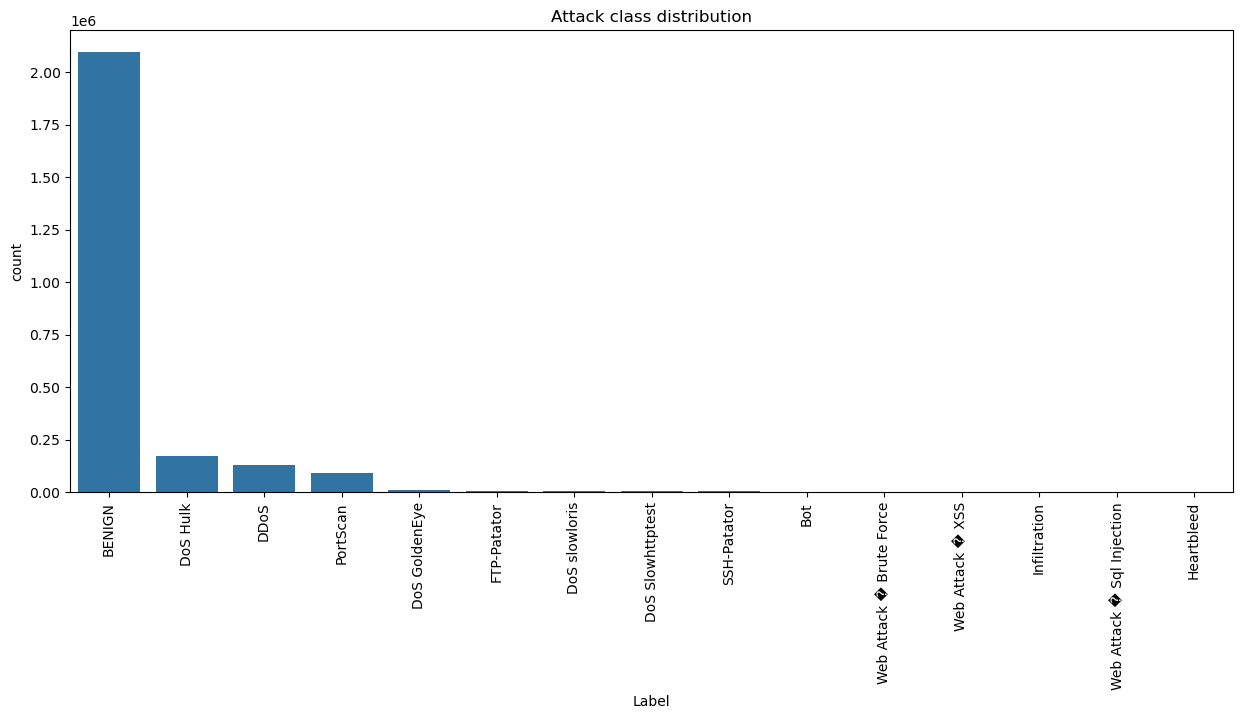

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15,6))

sns.countplot(
    x = combined_df["Label"],
    order= combined_df["Label"].value_counts().index
)
plt.xticks(rotation=90)
plt.title("Attack class distribution")
plt.show()

In [22]:
combined_df.dtypes

Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                           object
Length: 79, dtype: object

In [23]:
combined_df.select_dtypes(include=['object']).columns

Index(['Label'], dtype='object')

In [24]:
X = combined_df.drop(columns=['Label'])
y = combined_df['Label']

In [25]:
numeric_features = X.columns.tolist()
numeric_features

['Destination Port',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Min Packet Length',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'UR

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numeric_features)
    ]
)

In [28]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [29]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(2016638, 78)
(504160, 78)


In [30]:
# Removed notebook-specific command for portability
# !pip install tensorflow

^C


In [31]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [32]:
print(X_train_processed.shape)

(2016638, 78)


In [33]:
model = Sequential([
    Dense(128, activation='relu',input_shape=(X_train_processed.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(len(y.unique()), activation='softmax')
])

c:\Users\sidgu\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=512,
    callbacks=[early_stop]
)

ValueError: Invalid dtype: object

In [36]:
print(X_train_processed.dtype)

print(y_train.dtype)

print(type(X_train_processed))

print(type(y_train))

float64
object
<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>


In [37]:
y_train.head()

670011     BENIGN
1548214    BENIGN
18529      BENIGN
1108038    BENIGN
17177      BENIGN
Name: Label, dtype: object

In [38]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
combined_df['Label'] = label_encoder.fit_transform(
    combined_df['Label']
)

In [39]:
print(combined_df['Label'].head())

print(combined_df['Label'].dtype)


0    0
1    0
2    0
3    0
4    0
Name: Label, dtype: int64
int64


In [40]:
X = combined_df.drop(columns=['Label'])

y = combined_df['Label']

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
print(y_train.dtype)

print(y_train.head())

int64
670011     0
1548214    0
18529      0
1108038    0
17177      0
Name: Label, dtype: int64


In [44]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [45]:
import numpy as np

X_train_processed = np.asarray(X_train_processed).astype(np.float32)

X_test_processed = np.asarray(X_test_processed).astype(np.float32)

y_train = np.asarray(y_train).astype(np.int32)

y_test = np.asarray(y_test).astype(np.int32)

In [46]:
print(X_train_processed.dtype)

print(y_train.dtype)

float32
int32


In [47]:
history = model.fit(
    X_train_processed,
    y_train,

    validation_split=0.2,

    epochs=20,

    batch_size=512,

    callbacks=[early_stop]
)

Epoch 1/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - accuracy: 0.9573 - loss: 0.1384 - val_accuracy: 0.9767 - val_loss: 0.0562
Epoch 2/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - accuracy: 0.9738 - loss: 0.0661 - val_accuracy: 0.9777 - val_loss: 0.0495
Epoch 3/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - accuracy: 0.9757 - loss: 0.0581 - val_accuracy: 0.9788 - val_loss: 0.0444
Epoch 4/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - accuracy: 0.9775 - loss: 0.0537 - val_accuracy: 0.9814 - val_loss: 0.0414
Epoch 5/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - accuracy: 0.9785 - loss: 0.0504 - val_accuracy: 0.9816 - val_loss: 0.0393
Epoch 6/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - accuracy: 0.9793 - loss: 0.0485 - val_accuracy: 0.9817 - val_loss: 0.0416
Epoch 7/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - accuracy: 0.9800 - loss: 0.0482 - val_accuracy: 0.9851 - val_loss: 0.0362
Epoch 8/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - accuracy: 0.9806 -

In [48]:
y_pred_probs = model.predict(X_test_processed)



15755/15755 ━━━━━━━━━━━━━━━━━━━━ 72s 5ms/step


In [49]:
y_pred = np.argmax(y_pred_probs, axis=1)

In [50]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(classification_report(y_test, y_pred))

c:\Users\sidgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sidgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           0       1.00      0.99      1.00    419012
           1       0.97      0.34      0.51       390
           2       1.00      1.00      1.00     25603
           3       0.99      0.97      0.98      2057
           4       0.95      1.00      0.97     34569
           5       0.88      0.96      0.92      1046
           6       0.96      0.96      0.96      1077
           7       0.98      0.98      0.98      1186
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       0.97      0.99      0.98     18139
          11       1.00      0.90      0.95       644
          12       0.00      0.00      0.00       294
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       130

    accuracy                           0.99    504160
   macro avg       0.65      0.61      0.62    504160
weighted avg       0.99   

c:\Users\sidgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[416556      4     30     25   1717    128     18      4      0      0
     530      0      0      0      0]
 [   256    134      0      0      0      0      0      0      0      0
       0      0      0      0      0]
 [    41      0  25549      4      9      0      0      0      0      0
       0      0      0      0      0]
 [    68      0      0   1988      0      0      1      0      0      0
       0      0      0      0      0]
 [   154      0      0      0  34415      0      0      0      0      0
       0      0      0      0      0]
 [    14      0      0      0      0   1009     23      0      0      0
       0      0      0      0      0]
 [    13      0      0      0      0     14   1031     19      0      0
       0      0      0      0      0]
 [    19      0      0      0      0      0      0   1167      0      0
       0      0      0      0      0]
 [     2      0      0      0      0      0      0      0      0      0
       0      0      0      0      0]
 [     7  

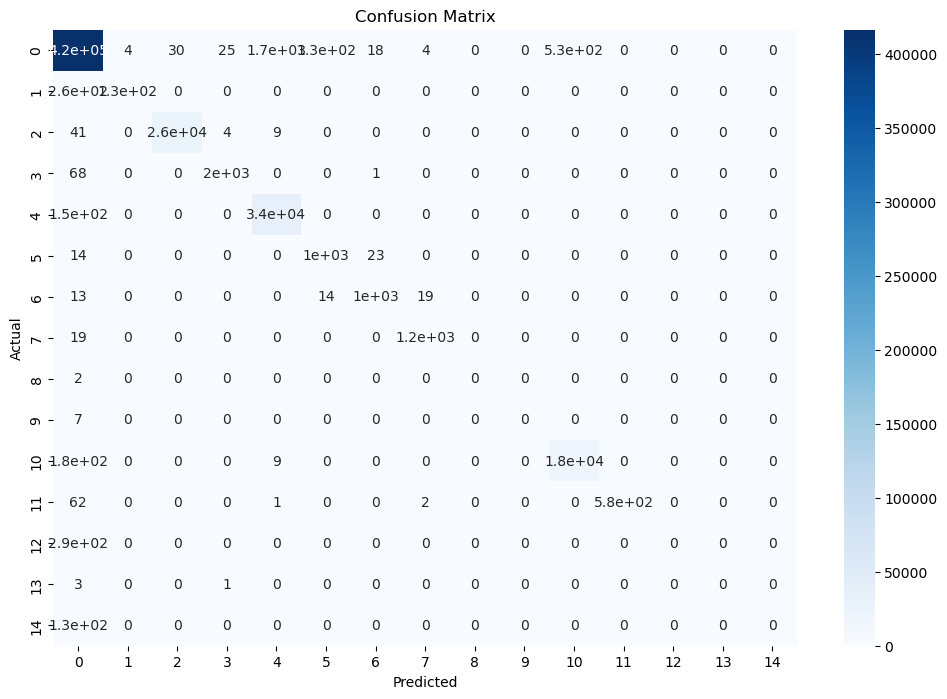

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(cm, annot=True, cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

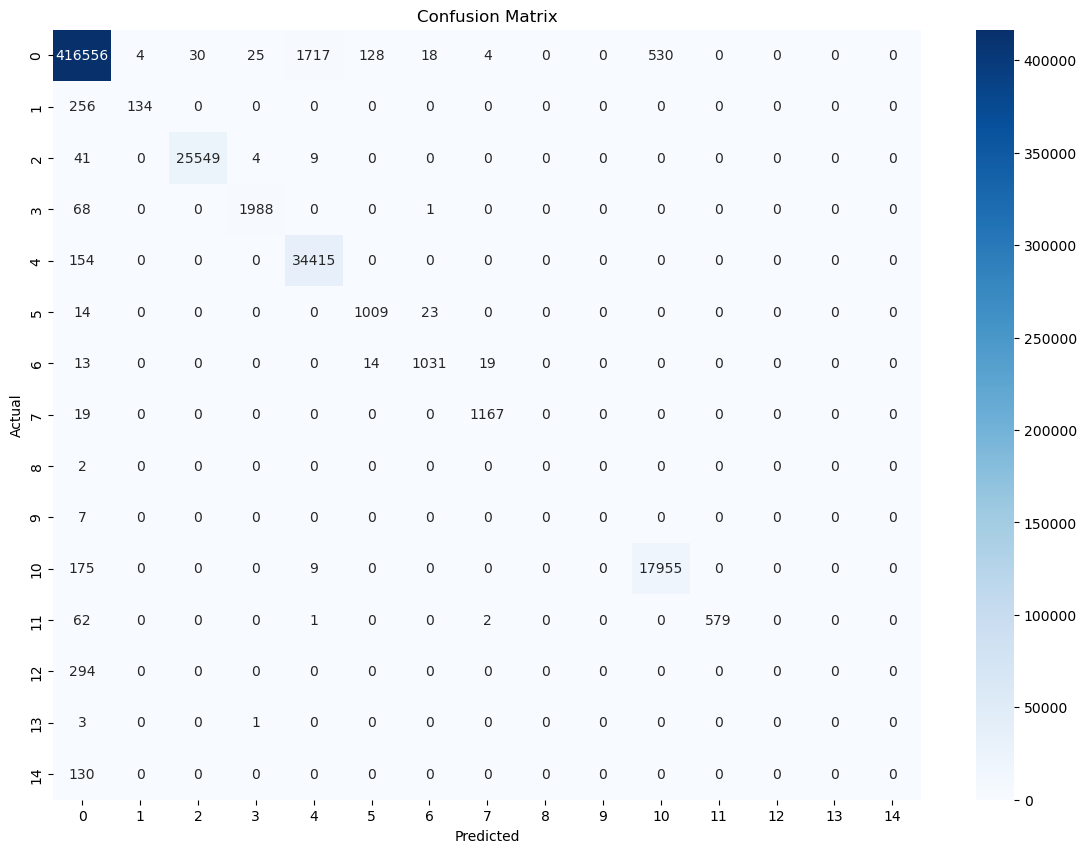

In [53]:
plt.figure(figsize=(14,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [54]:
print(classification_report(y_test, y_pred))

c:\Users\sidgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sidgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           0       1.00      0.99      1.00    419012
           1       0.97      0.34      0.51       390
           2       1.00      1.00      1.00     25603
           3       0.99      0.97      0.98      2057
           4       0.95      1.00      0.97     34569
           5       0.88      0.96      0.92      1046
           6       0.96      0.96      0.96      1077
           7       0.98      0.98      0.98      1186
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       0.97      0.99      0.98     18139
          11       1.00      0.90      0.95       644
          12       0.00      0.00      0.00       294
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       130

    accuracy                           0.99    504160
   macro avg       0.65      0.61      0.62    504160
weighted avg       0.99   

c:\Users\sidgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [55]:
print(label_mapping)

NameError: name 'label_mapping' is not defined

In [56]:
label_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

In [57]:
print(label_mapping)

{'BENIGN': np.int64(0), 'Bot': np.int64(1), 'DDoS': np.int64(2), 'DoS GoldenEye': np.int64(3), 'DoS Hulk': np.int64(4), 'DoS Slowhttptest': np.int64(5), 'DoS slowloris': np.int64(6), 'FTP-Patator': np.int64(7), 'Heartbleed': np.int64(8), 'Infiltration': np.int64(9), 'PortScan': np.int64(10), 'SSH-Patator': np.int64(11), 'Web Attack � Brute Force': np.int64(12), 'Web Attack � Sql Injection': np.int64(13), 'Web Attack � XSS': np.int64(14)}


targeted inbalance analysis

In [58]:
class_counts = combined_df['Label'].value_counts()

print(class_counts.sort_values())

Label
8          11
13         21
9          36
14        652
12       1470
1        1948
11       3219
5        5228
6        5385
7        5931
3       10286
10      90694
2      128014
4      172846
0     2095057
Name: count, dtype: int64


In [59]:
label_mapping

{'BENIGN': np.int64(0),
 'Bot': np.int64(1),
 'DDoS': np.int64(2),
 'DoS GoldenEye': np.int64(3),
 'DoS Hulk': np.int64(4),
 'DoS Slowhttptest': np.int64(5),
 'DoS slowloris': np.int64(6),
 'FTP-Patator': np.int64(7),
 'Heartbleed': np.int64(8),
 'Infiltration': np.int64(9),
 'PortScan': np.int64(10),
 'SSH-Patator': np.int64(11),
 'Web Attack � Brute Force': np.int64(12),
 'Web Attack � Sql Injection': np.int64(13),
 'Web Attack � XSS': np.int64(14)}

In [60]:
class_counts = combined_df['Label'].value_counts()

print(class_counts.sort_values())

Label
8          11
13         21
9          36
14        652
12       1470
1        1948
11       3219
5        5228
6        5385
7        5931
3       10286
10      90694
2      128014
4      172846
0     2095057
Name: count, dtype: int64


In [61]:
minority_classes = [
    label_mapping['Web Attack � Brute Force'],
    label_mapping['SSH-Patator'],
    label_mapping['FTP-Patator'],
    label_mapping['Web Attack � XSS']
]

In [62]:
print(label_mapping.keys())

dict_keys(['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS'])


In [63]:
minority_df = combined_df[
    combined_df['Label'].isin(minority_classes)
]

In [64]:
print(minority_df['Label'].value_counts())

Label
7     5931
11    3219
12    1470
14     652
Name: count, dtype: int64


In [65]:
gan_X = minority_df.drop(columns=['Label'])

In [66]:
gan_numeric_features = gan_X.columns.tolist()

In [67]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler

In [68]:
gan_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            MinMaxScaler(feature_range=(-1, 1)),
            gan_numeric_features
        )
    ]
)

In [69]:
from sklearn.pipeline import Pipeline
gan_pipeline = Pipeline([
    ('preprocessor', gan_preprocessor)
])

In [70]:
gan_data_scaled = gan_pipeline.fit_transform(gan_X)

In [71]:
import numpy as np

gan_data_scaled = np.asarray(
    gan_data_scaled
).astype(np.float32)

In [72]:
print(gan_data_scaled.shape)

print(gan_data_scaled.dtype)

(11272, 78)
float32


In [73]:
print(gan_data_scaled.shape)

(11272, 78)


In [74]:
feature_dim = gan_data_scaled.shape[1]
noise_dim = 100

In [75]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
generator = Sequential([
    Dense(128,activation='relu',input_dim = noise_dim),
    Dense(256,activation='relu'),
    Dense(512,activation='relu'),
    Dense(feature_dim,activation='tanh')
])

c:\Users\sidgu\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [76]:
from tensorflow.keras.layers import Dropout

discrimonator = Sequential([
    Dense(512,activation='relu',input_dim=feature_dim),
    Dropout(0.3),
    Dense(256,activation='relu'),
    Dropout(0.3),
    Dense(128,activation='relu'),
    Dense(1,activation='sigmoid')
])

In [77]:
from tensorflow.keras.optimizers import Adam

discrimonator.compile(
    optimizer = Adam(learning_rate = 0.0002),
    loss = 'binary_crossentropy',
    metrics=['accuracy']
    )

In [78]:
generator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 78)             │        40,014 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 217,550 (849.80 KB)

 Trainable params: 217,550 (849.80 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
discrimonator.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │        40,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,801 (800.00 KB)

 Trainable params: 204,801 (800.00 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
generator.output_shape

(None, 78)

In [81]:
print(feature_dim)
print(generator.output_shape)
print(discrimonator.output_shape)

78
(None, 78)
(None, 1)


In [82]:
discrimonator.trainable = False

In [83]:
gan = Sequential([
    generator,
    discrimonator
])

In [84]:
gan.compile(
    optimizer=Adam(learning_rate=0.0002),
    loss = 'binary_crossentropy'
)

In [85]:
gan.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 78)             │       217,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 1)              │       204,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,351 (1.61 MB)

 Trainable params: 217,550 (849.80 KB)

 Non-trainable params: 204,801 (800.00 KB)

In [86]:
print(gan_data_scaled.shape)

(11272, 78)


In [87]:
batch_size = 64

epochs = 2000

In [88]:
import numpy as np
real_labels = np.ones((batch_size,1))
fake_labels = np.zeros((batch_size,1))

In [89]:
for epoch in range(epochs):
    # idx = np.random.randint(
    #     0,
    #     1,
    #     (batch_size,noise_dim)
    # )  invalid dimentions
    idx = np.random.randint(
    0,
    gan_data_scaled.shape[0],
    batch_size
)
    real_samples = gan_data_scaled[idx]
    
    noise = np.random.normal(
        0,
        1,
        (batch_size,noise_dim)
    )
    fake_samples = generator.predict(
        noise,
        verbose=1
    )

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━

In [90]:
print(noise.shape)
print(fake_samples.shape)
print(real_samples.shape)

(64, 100)
(64, 78)
(64, 78)


In [91]:
d_loss_real = discrimonator.train_on_batch(
    real_samples,
    real_labels
)

c:\Users\sidgu\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


In [92]:
real_labels.shape

(64, 1)

In [93]:
d_loss_fake = discrimonator.train_on_batch(
    fake_samples,
    fake_labels
)

In [94]:
d_loss = 0.5*np.add(
    d_loss_real,
    d_loss_fake
)

In [95]:
g_loss  = gan.train_on_batch(
    noise,
    real_labels
)


In [96]:
gan.train_on_batch(
    noise,
    real_labels
)

0.6783310174942017

In [97]:
if epoch % 100:
    print(
        f"epoch {epoch}"
        f"D loss {d_loss[0]:.4f}"
        f"D acc: {100*d_loss[1]:.2f}% | "
        f"G loss: {g_loss:.4f}"
    )

epoch 1999D loss 0.8014D acc: 27.73% | G loss: 0.6861


In [98]:
noise = np.random.normal(
    0,
    1,
    (1000, noise_dim)
)

synthetic_samples = generator.predict(noise)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [99]:
print(synthetic_samples.shape)

(1000, 78)


In [100]:
synthetic_original = gan_pipeline.inverse_transform(
    synthetic_samples
)

AttributeError: This 'Pipeline' has no attribute 'inverse_transform'

In [101]:
print(type(gan_pipeline))

<class 'sklearn.pipeline.Pipeline'>


In [102]:
print(type(gan_preprocessor))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [103]:
print(gan_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  MinMaxScaler(feature_range=(-1,
                                                                              1)),
                                                  ['Destination Port',
                                                   'Flow Duration',
                                                   'Total Fwd Packets',
                                                   'Total Backward Packets',
                                                   'Total Length of Fwd '
                                                   'Packets',
                                                   'Total Length of Bwd '
                                                   'Packets',
                                                   'Fwd Packet Length Max',
                                                   'Fwd Packet Length Min',
                                 

In [104]:
print(gan_pipeline.named_steps)

{'preprocessor': ColumnTransformer(transformers=[('num', MinMaxScaler(feature_range=(-1, 1)),
                                 ['Destination Port', 'Flow Duration',
                                  'Total Fwd Packets', 'Total Backward Packets',
                                  'Total Length of Fwd Packets',
                                  'Total Length of Bwd Packets',
                                  'Fwd Packet Length Max',
                                  'Fwd Packet Length Min',
                                  'Fwd Packet Length Mean',
                                  'Fwd Packet Length Std',
                                  'Bwd Packet Length Max',
                                  'Bwd Packet Length Min',
                                  'Bwd Packet Length Mean',
                                  'Bwd Packet Length Std', 'Flow Bytes/s',
                                  'Flow Packets/s', 'Flow IAT Mean',
                                  'Flow IAT Std', 'Flow IAT Max',

In [105]:
gan_pipeline.named_steps['preprocessor']

,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,feature_range,"(-1, ...)"
,copy,True
,clip,False


In [106]:
fitted_scaler = gan_pipeline.named_steps['preprocessor'].named_transformers_['num']

In [107]:
print(type(fitted_scaler))

<class 'sklearn.preprocessing._data.MinMaxScaler'>


In [108]:
synthetic_original = fitted_scaler.inverse_transform(
    synthetic_samples

)

In [109]:
synthetic_df = pd.DataFrame(
    synthetic_original,
    columns = gan_X.columns
)
synthetic_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,44.981628,65668040.0,138.273361,49.569969,32450.894531,92089.835938,487.225891,11.555019,141.542969,159.883652,...,58.845238,36.651505,0.577085,0.341106,0.189912,0.559483,0.400463,0.456646,0.536432,0.418085
1,53.902744,65735788.0,147.968384,49.473339,25708.560547,109310.812500,569.860168,16.926394,126.005920,191.491364,...,45.846127,36.133057,0.267103,0.297146,0.145339,0.453086,0.277799,0.394991,0.511277,0.273655
2,50.204803,65136704.0,125.757195,57.108086,17725.193359,112473.312500,622.082275,10.765507,153.125671,199.705215,...,44.325100,36.032631,0.562296,0.388274,0.222687,0.375247,0.325004,0.678745,0.519258,0.337914
3,50.524158,52331064.0,127.322426,46.852715,29948.031250,97292.562500,784.584900,13.199727,120.132820,225.280334,...,39.280727,32.778011,0.546740,0.412359,0.313018,0.458747,0.377115,0.579531,0.473689,0.464756
4,49.495296,71252600.0,138.392822,36.408028,25617.113281,104173.015625,873.298157,11.958867,146.111694,213.276337,...,54.512360,34.987026,0.523915,0.424544,0.163558,0.373765,0.411356,0.578696,0.395462,0.337896


In [110]:
print(type(fitted_scaler))

<class 'sklearn.preprocessing._data.MinMaxScaler'>


In [111]:
gan_X.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,11272.000000,1.127200e+04,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,...,11272.000000,11272.000000,11272.0,11272.0,11272.0,11272.0,11272.0,11272.0,11272.0,11272.0
mean,32.397800,7.663888e+06,11.205908,14.871984,919.003460,1516.698811,187.614354,0.010468,33.105093,45.578420,...,7.097232,32.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,22.935642,5.589502e+06,18.461010,14.522465,3958.095685,8911.684277,278.718131,0.434797,43.193299,63.525216,...,10.384659,0.226063,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,21.000000,1.000000e+00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,20.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,21.000000,5.224847e+06,3.000000,1.000000,14.000000,0.000000,14.000000,0.000000,7.000000,8.823894,...,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,21.000000,8.810156e+06,9.000000,15.000000,104.000000,188.000000,23.000000,0.000000,11.555556,9.899495,...,6.000000,32.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,22.000000,1.101128e+07,19.000000,31.000000,2008.000000,2745.000000,640.000000,0.000000,87.304348,137.423089,...,16.000000,32.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,80.000000,1.198167e+08,212.000000,114.000000,48985.000000,183700.000000,1432.000000,24.000000,241.305419,377.895735,...,101.000000,44.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [112]:
synthetic_df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,1000.000000,1000.0,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,48.160072,55759980.0,121.124153,43.214493,24869.148438,108940.523438,731.478516,12.524897,127.028465,224.017059,...,47.214893,34.433041,0.546003,0.384169,0.238843,0.460840,0.336693,0.500100,0.520941,0.398715
std,4.709550,9430813.0,20.534290,9.868192,4287.591309,14579.589844,140.039490,2.002338,19.855154,31.596130,...,8.177710,1.751483,0.084795,0.088981,0.068312,0.084989,0.071398,0.096947,0.078573,0.079202
min,33.931824,22698356.0,62.156288,13.018195,11957.508789,59137.558594,314.960968,6.632933,71.857315,128.077454,...,24.421618,28.957123,0.258867,0.096898,0.073317,0.200314,0.143960,0.212663,0.239801,0.152311
25%,44.929943,49615250.0,106.708536,36.357107,21853.879395,99385.986328,632.914139,11.216967,114.578077,201.979797,...,41.882978,33.217864,0.489290,0.323798,0.193546,0.405916,0.285217,0.435302,0.467136,0.346088
50%,48.003069,55667890.0,121.998165,43.037287,24827.452148,108860.863281,733.120300,12.615311,127.074657,223.812881,...,47.065495,34.330519,0.550549,0.382297,0.232908,0.460222,0.335286,0.496699,0.519222,0.398112
75%,51.369762,61972587.0,135.672943,50.084618,27716.913574,118797.427734,827.143539,13.841649,140.337757,247.596066,...,52.580298,35.621100,0.604783,0.441335,0.282245,0.517891,0.386796,0.566759,0.575275,0.451682
max,62.131100,82354592.0,171.360428,73.029167,39633.433594,160376.562500,1188.664062,17.823444,193.833954,311.100220,...,72.092949,39.935497,0.746935,0.650939,0.517678,0.738456,0.594336,0.796015,0.771805,0.658876


In [113]:
print(gan_data_scaled.mean())
print(synthetic_samples.mean())

print(gan_data_scaled.std())
print(synthetic_samples.std())

-0.8268239
-0.01279737
0.45093554
0.29026788


above GAN model is fed garbage data so build new correct one

In [114]:
minority_classes = [
    label_mapping['FTP-Patator'],
    label_mapping['SSH-Patator'],
    label_mapping['Web Attack � Brute Force'],
    label_mapping['Web Attack � XSS']
]

minority_df = combined_df[
    combined_df['Label'].isin(minority_classes)
].copy()

In [115]:
gan_X = minority_df.drop(columns=['Label'])

In [116]:
zero_var_cols = gan_X.columns[
    gan_X.nunique() <= 1
]

print("Number of constant columns:", len(zero_var_cols))
print(zero_var_cols.tolist())

Number of constant columns: 23
['Bwd Packet Length Min', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Min Packet Length', 'FIN Flag Count', 'RST Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min']


In [117]:
gan_X_reduced = gan_X.drop(
    columns=zero_var_cols
)

print(gan_X_reduced.shape)

(11272, 55)


In [118]:
from sklearn.preprocessing import MinMaxScaler

gan_scaler = MinMaxScaler(
    feature_range=(-1, 1)
)

gan_data_scaled = gan_scaler.fit_transform(
    gan_X_reduced
)

In [119]:
print(gan_data_scaled.shape)

(11272, 55)


In [120]:
print(gan_X_reduced.shape)
print(gan_data_scaled.shape)

(11272, 55)
(11272, 55)


In [121]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam

In [122]:
feature_dim = gan_data_scaled.shape[1]

noise_dim = 100

print(feature_dim)

55


In [123]:
generator = Sequential([
    
    Dense(
        256,
        activation='relu',
        input_dim=noise_dim
    ),

    BatchNormalization(),

    Dense(
        512,
        activation='relu'
    ),

    BatchNormalization(),

    Dense(
        256,
        activation='relu'
    ),

    Dense(
        feature_dim,
        activation='tanh'
    )
])

generator.summary()

c:\Users\sidgu\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 55)             │        14,135 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,975 (1.17 MB)

 Trainable params: 304,439 (1.16 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [124]:
generator.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 55)             │        14,135 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,975 (1.17 MB)

 Trainable params: 304,439 (1.16 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [125]:
discriminator = Sequential([

    Dense(
        256,
        activation='relu',
        input_dim=feature_dim
    ),

    Dropout(0.3),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )

])

discriminator.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 256)            │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,553 (217.00 KB)

 Trainable params: 55,553 (217.00 KB)

 Non-trainable params: 0 (0.00 B)

In [126]:
optimizer = Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

In [127]:
discriminator.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

In [128]:
discriminator.trainable = False

In [129]:
gan = Sequential([
    generator,
    discriminator
])

In [130]:
gan.compile(
    loss='binary_crossentropy',
    optimizer=optimizer
)

In [131]:
gan.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 55)             │       305,975 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 1)              │        55,553 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,528 (1.38 MB)

 Trainable params: 304,439 (1.16 MB)

 Non-trainable params: 57,089 (223.00 KB)

In [132]:
batch_size = 64

epochs = 5000

real_labels = np.ones((batch_size, 1))

fake_labels = np.zeros((batch_size, 1))

In [133]:
idx = np.random.randint(
    0,
    1,
    (batch_size, noise_dim)
)

In [134]:
noise = np.random.normal(
    0,
    1,
    (1000, noise_dim)
)

synthetic_samples = generator.predict(
    noise,
    verbose=0
)

synthetic_original = gan_scaler.inverse_transform(
    synthetic_samples
)

synthetic_df = pd.DataFrame(
    synthetic_original,
    columns=gan_X_reduced.columns
)

In [135]:
gan_X_reduced.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward
count,11272.000000,1.127200e+04,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,...,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000
mean,32.397800,7.663888e+06,11.205908,14.871984,919.003460,1516.698811,187.614354,0.010468,33.105093,45.578420,...,35.797295,365.090135,11.205908,919.003460,14.871984,1516.698811,23229.245209,4840.763928,7.097232,32.000000
std,22.935642,5.589502e+06,18.461010,14.522465,3958.095685,8911.684277,278.718131,0.434797,43.193299,63.525216,...,96.884312,591.742086,18.461010,3958.095685,14.522465,8911.684277,11710.373437,10581.601240,10.384659,0.226063
min,21.000000,1.000000e+00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,227.000000,-1.000000,0.000000,20.000000
25%,21.000000,5.224847e+06,3.000000,1.000000,14.000000,0.000000,14.000000,0.000000,7.000000,8.823894,...,0.000000,104.000000,3.000000,14.000000,1.000000,0.000000,29200.000000,227.000000,0.000000,32.000000
50%,21.000000,8.810156e+06,9.000000,15.000000,104.000000,188.000000,23.000000,0.000000,11.555556,9.899495,...,12.533333,296.000000,9.000000,104.000000,15.000000,188.000000,29200.000000,227.000000,6.000000,32.000000
75%,22.000000,1.101128e+07,19.000000,31.000000,2008.000000,2745.000000,640.000000,0.000000,87.304348,137.423089,...,83.181818,616.000000,19.000000,2008.000000,31.000000,2745.000000,29200.000000,247.000000,16.000000,32.000000
max,80.000000,1.198167e+08,212.000000,114.000000,48985.000000,183700.000000,1432.000000,24.000000,241.305419,377.895735,...,1773.202532,6792.000000,212.000000,48985.000000,114.000000,183700.000000,29200.000000,28960.000000,101.000000,44.000000


In [136]:
synthetic_df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward
count,1000.000000,1000.0,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,44.931290,62582300.0,119.829063,53.645226,31909.259766,96651.179688,871.143860,17.027952,112.803108,260.367889,...,1196.432983,3020.167480,126.187546,23221.664062,46.637756,70351.523438,13702.306641,16646.304688,49.008877,32.071327
std,5.999011,11108627.0,19.072416,10.058868,4528.751953,18540.875000,138.555573,2.125690,22.303629,34.700489,...,163.863708,646.476624,18.516613,4786.265625,10.208112,16439.919922,2455.209961,2654.567871,9.673312,2.180762
min,29.049185,28945422.0,60.466209,24.956087,15564.503906,39766.386719,335.251709,9.549731,51.329037,119.006287,...,574.397461,1014.470154,66.438438,9678.915039,18.391998,24422.132812,6296.965820,7567.184570,17.351669,24.482677
25%,40.465997,54893793.0,106.438623,46.731051,28591.025879,84585.212891,778.751419,15.595820,97.683344,237.223907,...,1085.012177,2543.110718,113.921036,19833.207031,39.625147,58857.365234,12075.643555,14913.350586,42.215212,30.449308
50%,44.801659,62206662.0,120.136951,53.777956,32234.983398,96664.007812,872.835358,17.200075,111.992592,263.279358,...,1213.873291,3038.565796,126.247353,23175.469727,46.258802,69511.984375,13694.760254,16660.033203,48.562283,32.087648
75%,49.002401,70236536.0,132.619164,60.146637,35270.053711,109537.615234,962.648468,18.544129,128.639229,286.863998,...,1308.223450,3495.263184,139.008316,26444.274902,53.444894,80770.816406,15282.885742,18595.880859,55.537817,33.474005
max,66.889603,96564288.0,177.264679,83.589371,43764.972656,153213.640625,1292.610718,22.262672,182.433228,341.538879,...,1581.203491,4951.629883,186.225037,37335.000000,81.758568,132028.281250,22531.462891,23375.583984,80.091766,38.686348


In [137]:
cols = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets'
]

print(gan_X_reduced[cols].describe())
print(synthetic_df[cols].describe())

       Flow Duration  Total Fwd Packets  Total Backward Packets
count   1.127200e+04       11272.000000            11272.000000
mean    7.663888e+06          11.205908               14.871984
std     5.589502e+06          18.461010               14.522465
min     1.000000e+00           1.000000                0.000000
25%     5.224847e+06           3.000000                1.000000
50%     8.810156e+06           9.000000               15.000000
75%     1.101128e+07          19.000000               31.000000
max     1.198167e+08         212.000000              114.000000
       Flow Duration  Total Fwd Packets  Total Backward Packets
count         1000.0        1000.000000             1000.000000
mean      62582300.0         119.829063               53.645226
std       11108627.0          19.072416               10.058868
min       28945422.0          60.466209               24.956087
25%       54893793.0         106.438623               46.731051
50%       62206662.0         120.136951 

In [138]:
gan.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 55)             │       305,975 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 1)              │        55,553 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,528 (1.38 MB)

 Trainable params: 304,439 (1.16 MB)

 Non-trainable params: 57,089 (223.00 KB)

In [139]:
import numpy as np

batch_size = 64

epochs = 5000

real_labels = np.ones(
    (batch_size, 1)
)

fake_labels = np.zeros(
    (batch_size, 1)
)

In [140]:
for epoch in range(epochs):

    idx = np.random.randint(
        0,
        gan_data_scaled.shape[0],
        batch_size
    )

    real_samples = gan_data_scaled[idx]

In [141]:
print(real_samples.shape)

(64, 55)


In [142]:
noise = np.random.normal(
    0,
    1,
    (batch_size, noise_dim)
)

In [143]:
fake_samples = generator.predict(
    noise,
    verbose=0
)

In [144]:
print(real_samples.shape)
print(fake_samples.shape)

(64, 55)
(64, 55)


In [145]:
d_loss_real = discriminator.train_on_batch(
    real_samples,
    real_labels
)

c:\Users\sidgu\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


In [146]:
d_loss_fake = discriminator.train_on_batch(
    fake_samples,
    fake_labels
)

In [147]:
d_loss = 0.5 * np.add(
    d_loss_real,
    d_loss_fake
)

In [148]:
print(d_loss_real)
print(d_loss_fake)
print(d_loss)

[0.8248583078384399, 0.328125]
[0.7271311283111572, 0.6015625]
[0.77599472 0.46484375]


In [149]:
noise = np.random.normal(
    0,
    1,
    (batch_size, noise_dim)
)

In [150]:
misleading_labels = np.ones(
    (batch_size, 1)
)

In [151]:
g_loss = gan.train_on_batch(
    noise,
    misleading_labels
)

In [152]:
for epoch in range(epochs):

    # Train Discriminator
    

    idx = np.random.randint(
        0,
        gan_data_scaled.shape[0],
        batch_size
    )

    real_samples = gan_data_scaled[idx]

    noise = np.random.normal(
        0,
        1,
        (batch_size, noise_dim)
    )

    fake_samples = generator.predict(
        noise,
        verbose=0
    )

    d_loss_real = discriminator.train_on_batch(
        real_samples,
        real_labels
    )

    d_loss_fake = discriminator.train_on_batch(
        fake_samples,
        fake_labels
    )

    d_loss = 0.5 * np.add(
        d_loss_real,
        d_loss_fake
    )

    
    # Train Generator

    noise = np.random.normal(
        0,
        1,
        (batch_size, noise_dim)
    )

    misleading_labels = np.ones(
        (batch_size, 1)
    )

    g_loss = gan.train_on_batch(
        noise,
        misleading_labels
    )


    # Progress


    if epoch % 100 == 0:

        print(
            f"Epoch {epoch} | "
            f"D Loss: {d_loss[0]:.4f} | "
            f"D Acc: {100*d_loss[1]:.2f}% | "
            f"G Loss: {g_loss:.4f}"
        )

Epoch 0 | D Loss: 0.7374 | D Acc: 57.55% | G Loss: 0.8472
Epoch 100 | D Loss: 0.8142 | D Acc: 31.18% | G Loss: 0.5489
Epoch 200 | D Loss: 0.9254 | D Acc: 24.81% | G Loss: 0.4306
Epoch 300 | D Loss: 0.9962 | D Acc: 22.58% | G Loss: 0.3795
Epoch 400 | D Loss: 1.0441 | D Acc: 21.47% | G Loss: 0.3496
Epoch 500 | D Loss: 1.0771 | D Acc: 20.76% | G Loss: 0.3298
Epoch 600 | D Loss: 1.1006 | D Acc: 20.29% | G Loss: 0.3159
Epoch 700 | D Loss: 1.1178 | D Acc: 19.92% | G Loss: 0.3058
Epoch 800 | D Loss: 1.1311 | D Acc: 19.68% | G Loss: 0.2975
Epoch 900 | D Loss: 1.1419 | D Acc: 19.53% | G Loss: 0.2915
Epoch 1000 | D Loss: 1.1506 | D Acc: 19.40% | G Loss: 0.2867
Epoch 1100 | D Loss: 1.1579 | D Acc: 19.26% | G Loss: 0.2823
Epoch 1200 | D Loss: 1.1638 | D Acc: 19.12% | G Loss: 0.2788
Epoch 1300 | D Loss: 1.1685 | D Acc: 19.00% | G Loss: 0.2758
Epoch 1400 | D Loss: 1.1725 | D Acc: 18.92% | G Loss: 0.2734
Epoch 1500 | D Loss: 1.1762 | D Acc: 18.90% | G Loss: 0.2711
Epoch 1600 | D Loss: 1.1798 | D Acc:

In [153]:
cols = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets'
]

print(gan_X_reduced[cols].describe())
print(synthetic_df[cols].describe())

       Flow Duration  Total Fwd Packets  Total Backward Packets
count   1.127200e+04       11272.000000            11272.000000
mean    7.663888e+06          11.205908               14.871984
std     5.589502e+06          18.461010               14.522465
min     1.000000e+00           1.000000                0.000000
25%     5.224847e+06           3.000000                1.000000
50%     8.810156e+06           9.000000               15.000000
75%     1.101128e+07          19.000000               31.000000
max     1.198167e+08         212.000000              114.000000
       Flow Duration  Total Fwd Packets  Total Backward Packets
count         1000.0        1000.000000             1000.000000
mean      62582300.0         119.829063               53.645226
std       11108627.0          19.072416               10.058868
min       28945422.0          60.466209               24.956087
25%       54893793.0         106.438623               46.731051
50%       62206662.0         120.136951 

In [154]:
from ctgan import CTGAN

In [155]:
minority_df.shape

(11272, 79)

In [156]:
ctgan_data = minority_df.drop(
    columns=['Label']
)

In [157]:
ctgan = CTGAN(
    epochs=300
)

In [158]:
print(ctgan_data.shape)
print(ctgan_data.dtypes.value_counts())

(11272, 78)
int64      54
float64    24
Name: count, dtype: int64


In [159]:
from ctgan import CTGAN

ctgan = CTGAN(
    epochs=50,
    verbose=True
)

ctgan.fit(ctgan_data)

Gen. (-01.59) | Discrim. (-00.38): 100%|██████████| 50/50 [04:23<00:00,  5.27s/it]


In [160]:
synthetic_df = ctgan.sample(1000)

In [161]:
cols = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets'
]

print(ctgan_data[cols].describe())
print(synthetic_df[cols].describe())

       Flow Duration  Total Fwd Packets  Total Backward Packets
count   1.127200e+04       11272.000000            11272.000000
mean    7.663888e+06          11.205908               14.871984
std     5.589502e+06          18.461010               14.522465
min     1.000000e+00           1.000000                0.000000
25%     5.224847e+06           3.000000                1.000000
50%     8.810156e+06           9.000000               15.000000
75%     1.101128e+07          19.000000               31.000000
max     1.198167e+08         212.000000              114.000000
       Flow Duration  Total Fwd Packets  Total Backward Packets
count   1.000000e+03        1000.000000             1000.000000
mean    8.216666e+06           9.373000               13.352000
std     4.412310e+06          11.541711               11.905286
min    -7.085870e+05           0.000000               -3.000000
25%     5.768558e+06           2.000000                1.000000
50%     8.771371e+06           8.000000 

In [162]:
constant_cols = [
    col for col in ctgan_data.columns
    if ctgan_data[col].nunique() <= 1
]

print(len(constant_cols))

23


In [163]:
ctgan_data_reduced = ctgan_data.drop(
    columns=constant_cols
)

In [164]:
from ctgan import CTGAN

ctgan = CTGAN(
    epochs=50,
    verbose=True
)

ctgan.fit(ctgan_data)

Gen. (-03.86) | Discrim. (-02.01): 100%|██████████| 50/50 [04:34<00:00,  5.48s/it]


In [165]:
synthetic_df = ctgan.sample(1000)

In [166]:
cols = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets'
]

print(ctgan_data[cols].describe())
print(synthetic_df[cols].describe())

       Flow Duration  Total Fwd Packets  Total Backward Packets
count   1.127200e+04       11272.000000            11272.000000
mean    7.663888e+06          11.205908               14.871984
std     5.589502e+06          18.461010               14.522465
min     1.000000e+00           1.000000                0.000000
25%     5.224847e+06           3.000000                1.000000
50%     8.810156e+06           9.000000               15.000000
75%     1.101128e+07          19.000000               31.000000
max     1.198167e+08         212.000000              114.000000
       Flow Duration  Total Fwd Packets  Total Backward Packets
count   1.000000e+03         1000.00000             1000.000000
mean    8.401284e+06            9.04600               15.430000
std     4.847660e+06            7.16891               12.809105
min    -5.851510e+05            0.00000               -1.000000
25%     5.787734e+06            2.00000                2.000000
50%     9.371050e+06            8.00000 

In [228]:
synthetic_df['Flow Duration'] = (
    synthetic_df['Flow Duration']
    .clip(lower=0)
)

synthetic_df['Total Backward Packets'] = (
    synthetic_df['Total Backward Packets']
    .clip(lower=0)
    .round()
)

In [229]:
cols = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets'
]

print(ctgan_data[cols].describe())
print(synthetic_df[cols].describe())

       Flow Duration  Total Fwd Packets  Total Backward Packets
count   1.127200e+04       11272.000000            11272.000000
mean    7.663888e+06          11.205908               14.871984
std     5.589502e+06          18.461010               14.522465
min     1.000000e+00           1.000000                0.000000
25%     5.224847e+06           3.000000                1.000000
50%     8.810156e+06           9.000000               15.000000
75%     1.101128e+07          19.000000               31.000000
max     1.198167e+08         212.000000              114.000000
       Flow Duration  Total Fwd Packets  Total Backward Packets
count   1.000000e+03         1000.00000              1000.00000
mean    8.408687e+06            9.04600                15.43100
std     4.834558e+06            7.16891                12.80786
min     0.000000e+00            0.00000                 0.00000
25%     5.787734e+06            2.00000                 2.00000
50%     9.371050e+06            8.00000 

tried more failed more again collapsed from below here but upward is best


In [167]:
# synthetic_df['Flow Duration'] = (
#     synthetic_df['Flow Duration']
#     .clip(lower=0)
# )

# synthetic_df['Total Fwd Packets'] = (
#     synthetic_df['Total Fwd Packets']
#     .clip(lower=0)
#     .round()
# )

# synthetic_df['Total Backward Packets'] = (
#     synthetic_df['Total Backward Packets']
#     .clip(lower=0)
#     .round()
# )

In [230]:
print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Destination Port', 'Flow Duration',
                                  'Total Fwd Packets', 'Total Backward Packets',
                                  'Total Length of Fwd Packets',
                                  'Total Length of Bwd Packets',
                                  'Fwd Packet Length Max',
                                  'Fwd Packet Length Min',
                                  'Fwd Packet Length Mean',
                                  'Fwd Packet Length Std',
                                  'Bwd Packet Length Max',
                                  'Bwd Packet Length Min',
                                  'Bwd Packet Length Mean',
                                  'Bwd Packet Length Std', 'Flow Bytes/s',
                                  'Flow Packets/s', 'Flow IAT Mean',
                                  'Flow IAT Std', 'Flow IAT Max',
                                  '

In [231]:
print(gan_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  MinMaxScaler(feature_range=(-1,
                                                                              1)),
                                                  ['Destination Port',
                                                   'Flow Duration',
                                                   'Total Fwd Packets',
                                                   'Total Backward Packets',
                                                   'Total Length of Fwd '
                                                   'Packets',
                                                   'Total Length of Bwd '
                                                   'Packets',
                                                   'Fwd Packet Length Max',
                                                   'Fwd Packet Length Min',
                                 

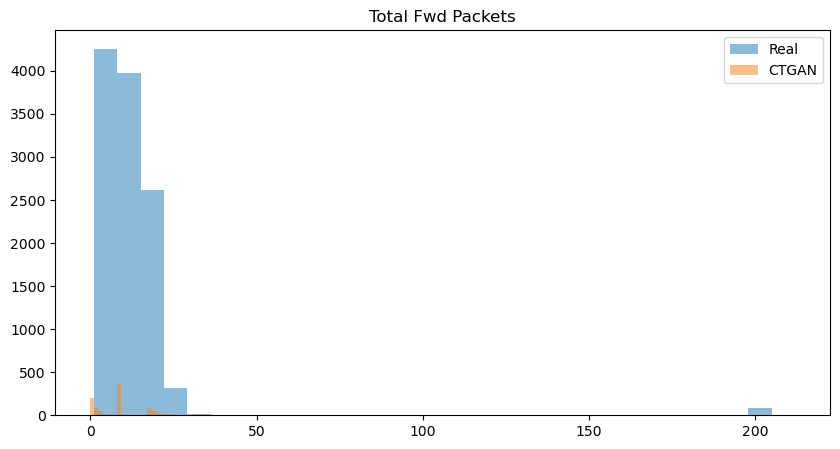

In [168]:
import matplotlib.pyplot as plt

feature = 'Total Fwd Packets'

plt.figure(figsize=(10,5))

plt.hist(
    ctgan_data[feature],
    bins=30,
    alpha=0.5,
    label='Real'
)

plt.hist(
    synthetic_df[feature],
    bins=30,
    alpha=0.5,
    label='CTGAN'
)

plt.legend()
plt.title(feature)
plt.show()

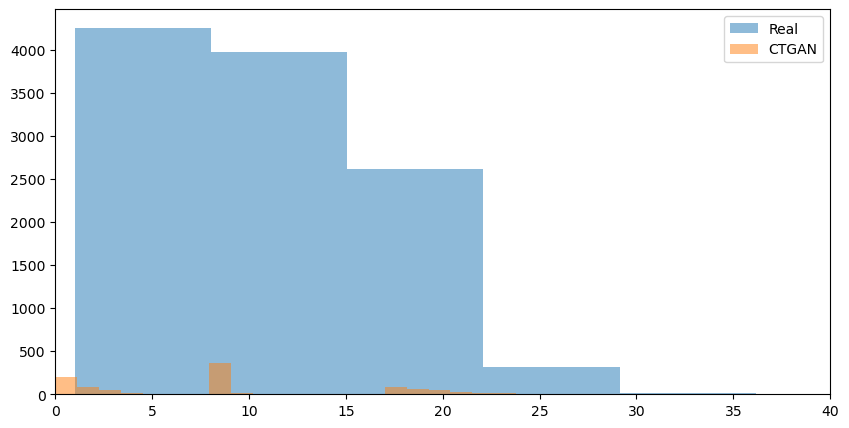

In [169]:
plt.figure(figsize=(10,5))

plt.hist(
    ctgan_data['Total Fwd Packets'],
    bins=30,
    alpha=0.5,
    label='Real'
)

plt.hist(
    synthetic_df['Total Fwd Packets'],
    bins=30,
    alpha=0.5,
    label='CTGAN'
)

plt.xlim(0, 40)

plt.legend()
plt.show()

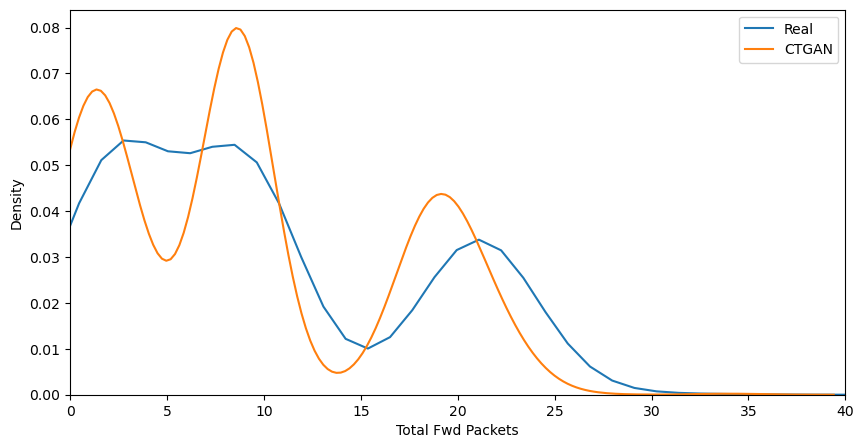

In [170]:
import seaborn as sns

plt.figure(figsize=(10,5))

sns.kdeplot(
    ctgan_data['Total Fwd Packets'],
    label='Real'
)

sns.kdeplot(
    synthetic_df['Total Fwd Packets'],
    label='CTGAN'
)

plt.xlim(0,40)

plt.legend()
plt.show()

In [232]:
real_labels = np.ones((batch_size, 1))
fake_labels = np.zeros((batch_size, 1))

In [244]:
vanilla_d_losses = d_losses.copy()
vanilla_g_losses = g_losses.copy()
vanilla_d_acc = d_accuracies.copy()

In [245]:
print(len(d_losses))
print(len(set(d_losses)))

print(len(g_losses))
print(len(set(g_losses)))

5000
4898
5000
4965


In [246]:
print(d_losses[:10])
print(g_losses[:10])
print(d_accuracies[:10])

[1.2172803282737732, 1.2172861099243164, 1.217290997505188, 1.2172942757606506, 1.2173045873641968, 1.217309057712555, 1.2173103094100952, 1.217316210269928, 1.2173138856887817, 1.2173165678977966]
[0.246251180768013, 0.24625054001808167, 0.24624688923358917, 0.2462441772222519, 0.24624702334403992, 0.24624621868133545, 0.24625113606452942, 0.24625042080879211, 0.24624218046665192, 0.2462427318096161]
[0.18331167846918106, 0.18331719934940338, 0.183319590985775, 0.1833188757300377, 0.18331346660852432, 0.1833166405558586, 0.18332137167453766, 0.18331284821033478, 0.1833214834332466, 0.18332543224096298]


In [247]:
print("D Loss")
print(min(d_losses))
print(max(d_losses))

print("\nG Loss")
print(min(g_losses))
print(max(g_losses))

print("\nD Accuracy")
print(min(d_accuracies))
print(max(d_accuracies))

D Loss
1.2172803282737732
1.2285603284835815

G Loss
0.23961372673511505
0.246251180768013

D Accuracy
0.18200819194316864
0.1833706870675087


In [240]:
import numpy as np

# Store metrics
d_losses = []
g_losses = []
d_accuracies = []

for epoch in range(epochs):

    # -------------------------
    # Train Discriminator
    # -------------------------

    idx = np.random.randint(
        0,
        gan_data_scaled.shape[0],
        batch_size
    )

    real_samples = gan_data_scaled[idx]

    noise = np.random.normal(
        0,
        1,
        (batch_size, noise_dim)
    )

    fake_samples = generator.predict(
        noise,
        verbose=0
    )

    real_labels = np.ones(
        (batch_size, 1)
    )

    fake_labels = np.zeros(
        (batch_size, 1)
    )

    d_loss_real = discriminator.train_on_batch(
        real_samples,
        real_labels
    )

    d_loss_fake = discriminator.train_on_batch(
        fake_samples,
        fake_labels
    )

    d_loss = 0.5 * np.add(
        d_loss_real,
        d_loss_fake
    )

    # -------------------------
    # Train Generator
    # -------------------------

    noise = np.random.normal(
        0,
        1,
        (batch_size, noise_dim)
    )

    misleading_labels = np.ones(
        (batch_size, 1)
    )

    g_loss = gan.train_on_batch(
        noise,
        misleading_labels
    )

    # -------------------------
    # Store Metrics
    # -------------------------

    d_losses.append(
        float(d_loss[0])
    )

    d_accuracies.append(
        float(d_loss[1])
    )

    g_losses.append(
        float(g_loss)
    )

    # -------------------------
    # Print Progress
    # -------------------------

    if epoch % 100 == 0:

        print(
            f"Epoch {epoch} | "
            f"D Loss: {d_loss[0]:.4f} | "
            f"D Acc: {100*d_loss[1]:.2f}% | "
            f"G Loss: {g_loss:.4f}"
        )

Epoch 0 | D Loss: 1.2173 | D Acc: 18.33% | G Loss: 0.2463
Epoch 100 | D Loss: 1.2177 | D Acc: 18.33% | G Loss: 0.2460
Epoch 200 | D Loss: 1.2180 | D Acc: 18.32% | G Loss: 0.2458
Epoch 300 | D Loss: 1.2184 | D Acc: 18.32% | G Loss: 0.2456
Epoch 400 | D Loss: 1.2188 | D Acc: 18.32% | G Loss: 0.2453
Epoch 500 | D Loss: 1.2191 | D Acc: 18.32% | G Loss: 0.2451
Epoch 600 | D Loss: 1.2195 | D Acc: 18.31% | G Loss: 0.2449
Epoch 700 | D Loss: 1.2199 | D Acc: 18.31% | G Loss: 0.2447
Epoch 800 | D Loss: 1.2202 | D Acc: 18.30% | G Loss: 0.2445
Epoch 900 | D Loss: 1.2204 | D Acc: 18.30% | G Loss: 0.2443
Epoch 1000 | D Loss: 1.2208 | D Acc: 18.30% | G Loss: 0.2442
Epoch 1100 | D Loss: 1.2210 | D Acc: 18.30% | G Loss: 0.2440
Epoch 1200 | D Loss: 1.2213 | D Acc: 18.30% | G Loss: 0.2438
Epoch 1300 | D Loss: 1.2216 | D Acc: 18.30% | G Loss: 0.2437
Epoch 1400 | D Loss: 1.2219 | D Acc: 18.30% | G Loss: 0.2435
Epoch 1500 | D Loss: 1.2221 | D Acc: 18.28% | G Loss: 0.2433
Epoch 1600 | D Loss: 1.2225 | D Acc:

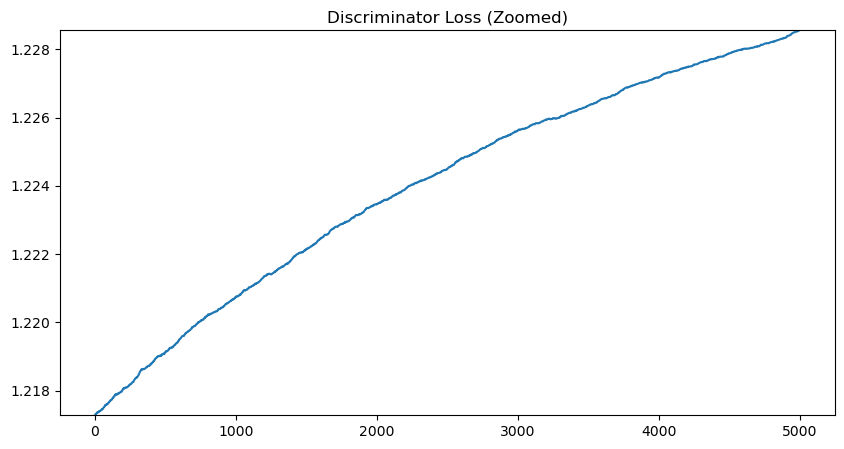

In [248]:
plt.figure(figsize=(10,5))

plt.plot(d_losses)

plt.ylim(
    min(d_losses),
    max(d_losses)
)

plt.title("Discriminator Loss (Zoomed)")
plt.show()

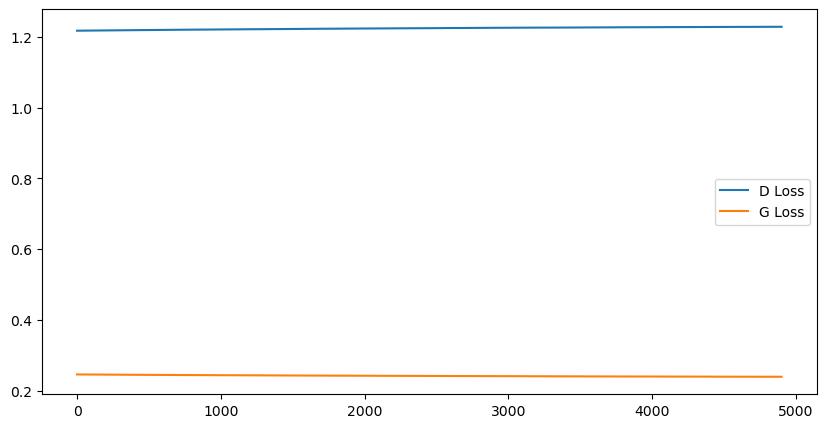

In [250]:
step = 100

plt.figure(figsize=(10,5))

plt.plot(
    range(0, len(d_losses), step),
    d_losses[::step],
    label="D Loss"
)

plt.plot(
    range(0, len(g_losses), step),
    g_losses[::step],
    label="G Loss"
)

plt.legend()
plt.show()

In [241]:
print(len(d_losses))
print(len(g_losses))
print(len(d_accuracies))

5000
5000
5000


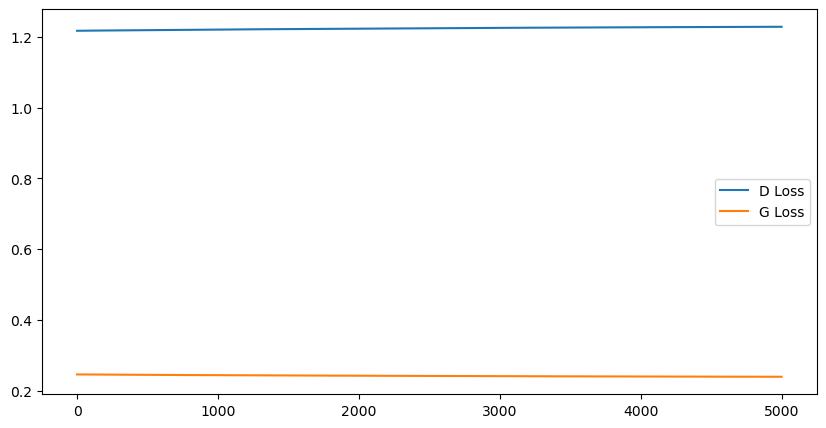

In [242]:
plt.figure(figsize=(10,5))
plt.plot(d_losses, label='D Loss')
plt.plot(g_losses, label='G Loss')
plt.legend()
plt.show()

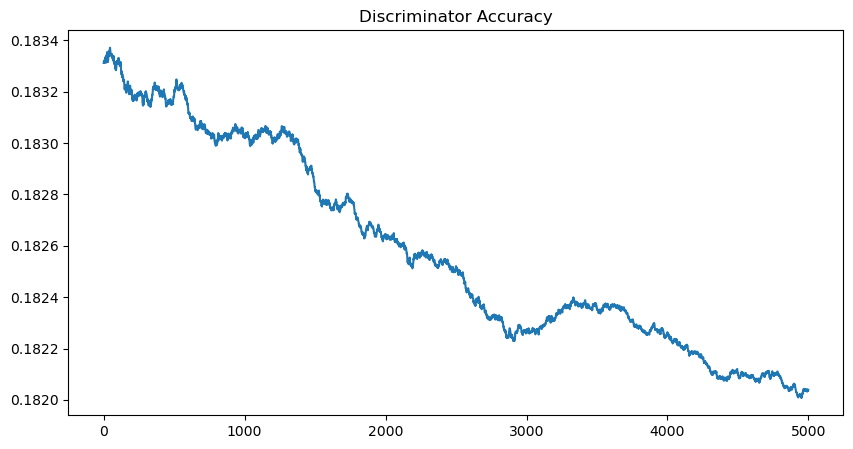

In [243]:
plt.figure(figsize=(10,5))
plt.plot(d_accuracies)
plt.title("Discriminator Accuracy")
plt.show()

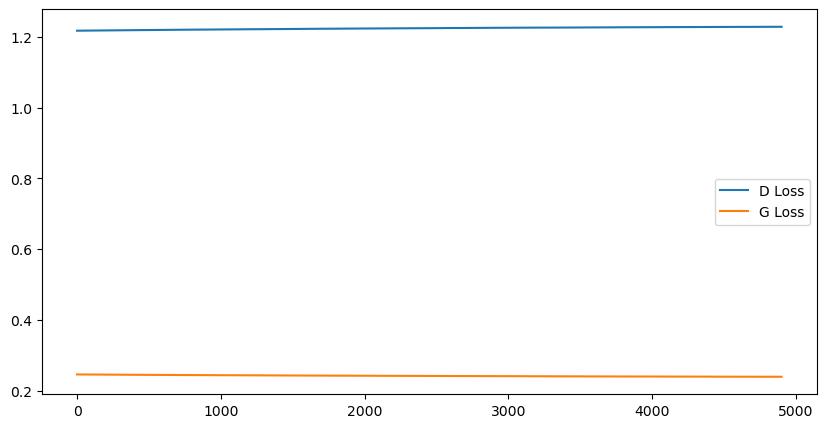

In [251]:
step = 100

plt.figure(figsize=(10,5))

plt.plot(
    range(0, len(d_losses), step),
    d_losses[::step],
    label="D Loss"
)

plt.plot(
    range(0, len(g_losses), step),
    g_losses[::step],
    label="G Loss"
)

plt.legend()
plt.show()

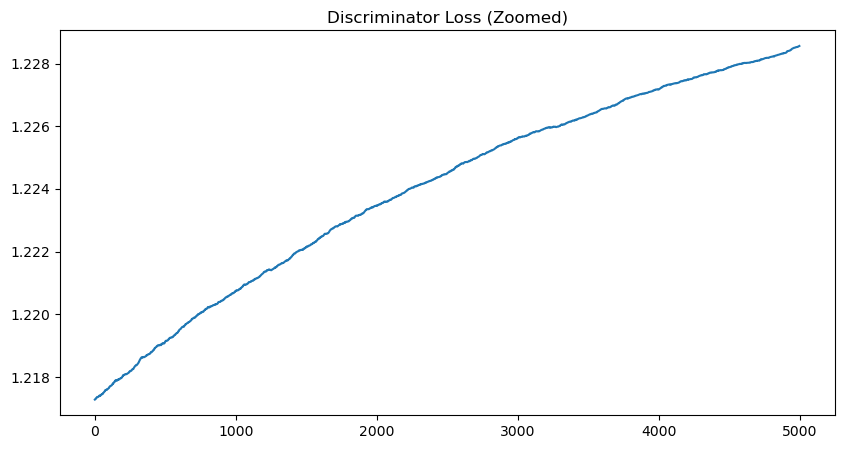

In [252]:
plt.figure(figsize=(10,5))

plt.plot(d_losses)

plt.ylim(
    min(d_losses) - 0.0005,
    max(d_losses) + 0.0005
)

plt.title("Discriminator Loss (Zoomed)")
plt.show()

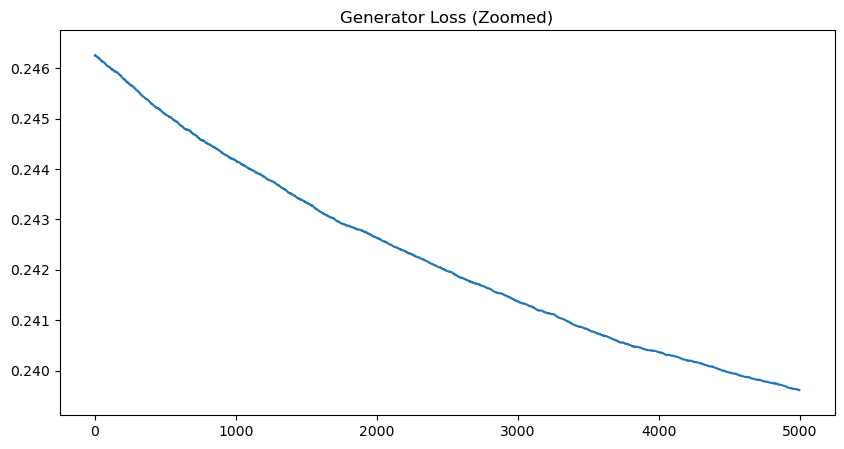

In [253]:
plt.figure(figsize=(10,5))

plt.plot(g_losses)

plt.ylim(
    min(g_losses) - 0.0005,
    max(g_losses) + 0.0005
)

plt.title("Generator Loss (Zoomed)")
plt.show()

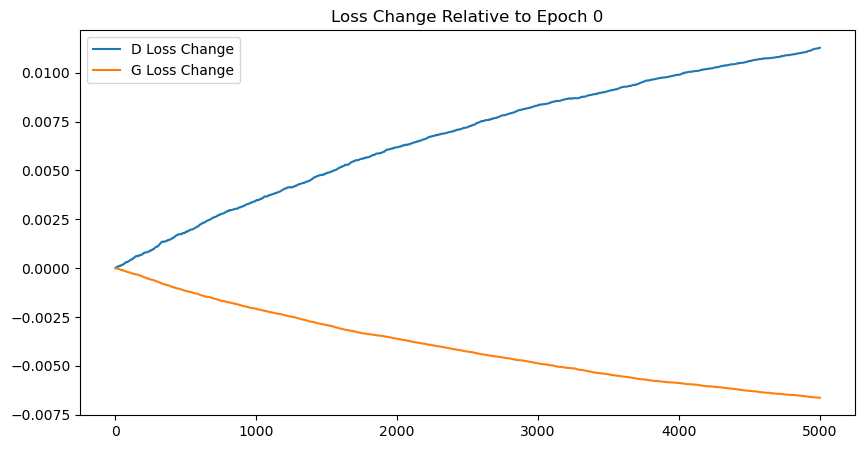

In [254]:
import numpy as np

d_norm = np.array(d_losses) - d_losses[0]
g_norm = np.array(g_losses) - g_losses[0]

plt.figure(figsize=(10,5))
plt.plot(d_norm, label='D Loss Change')
plt.plot(g_norm, label='G Loss Change')

plt.legend()
plt.title("Loss Change Relative to Epoch 0")
plt.show()

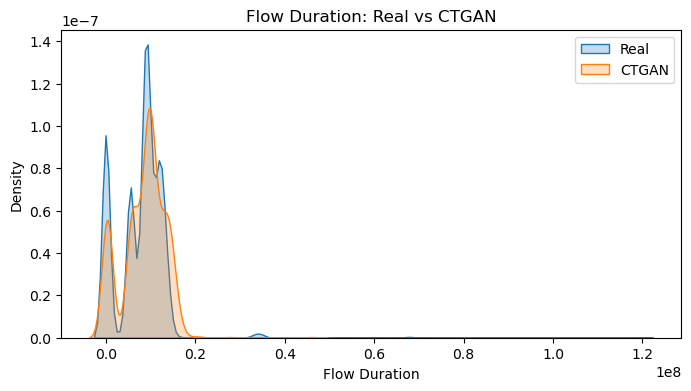

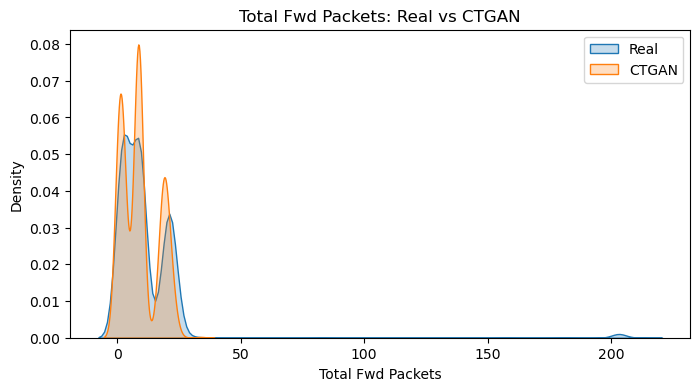

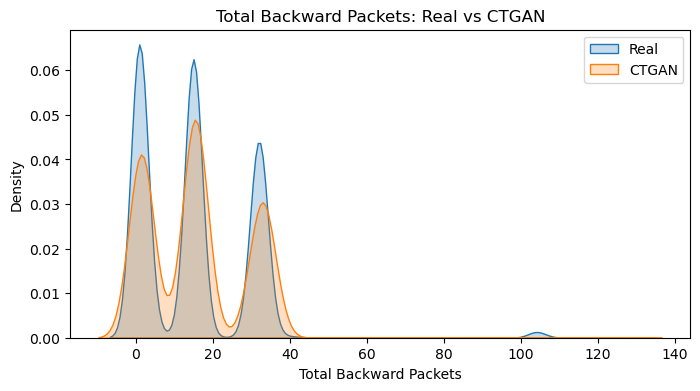

In [255]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets'
]

for col in cols:

    plt.figure(figsize=(8,4))

    sns.kdeplot(
        ctgan_data[col],
        label='Real',
        fill=True
    )

    sns.kdeplot(
        synthetic_df[col],
        label='CTGAN',
        fill=True
    )

    plt.title(f'{col}: Real vs CTGAN')
    plt.legend()

    plt.show()

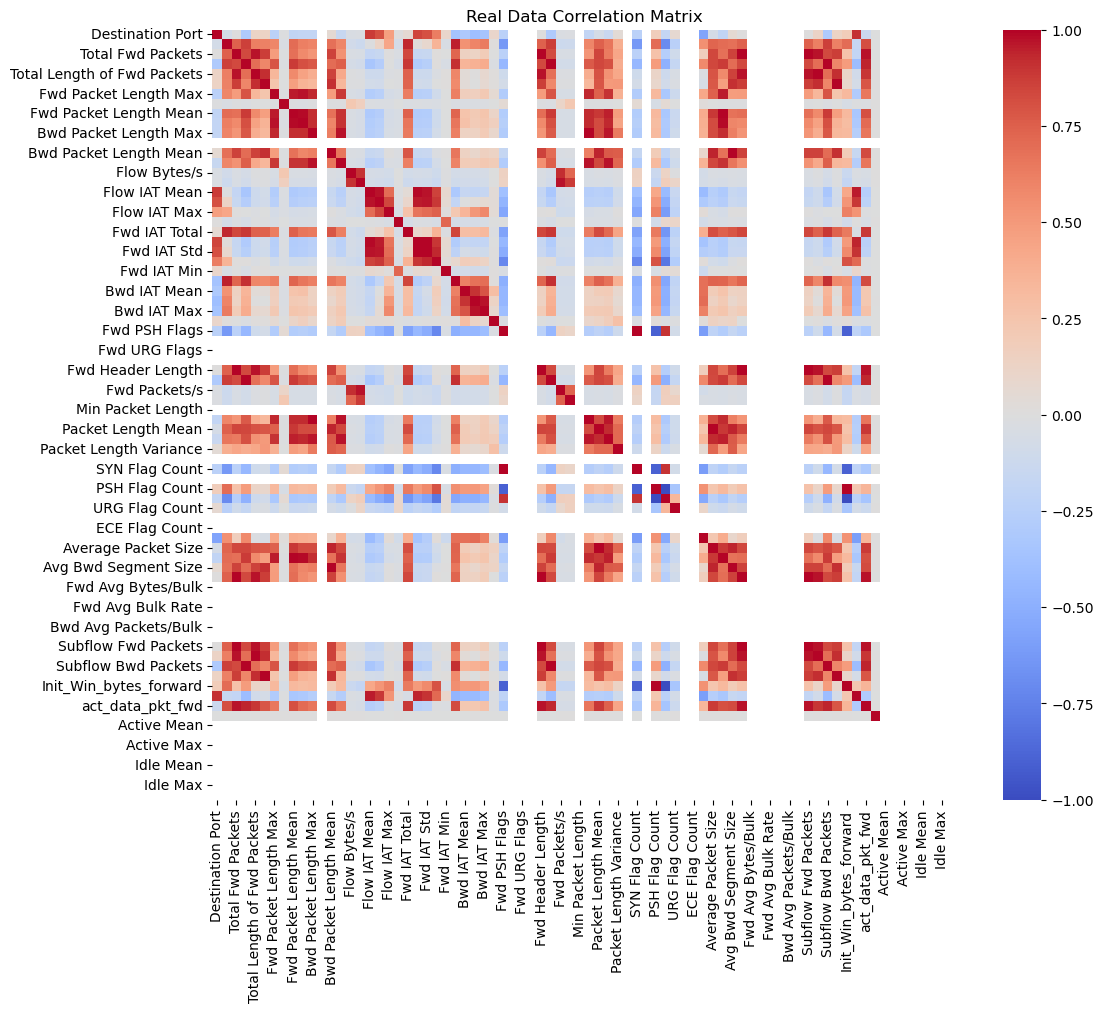

In [256]:
plt.figure(figsize=(12,10))

sns.heatmap(
    ctgan_data.corr(),
    cmap='coolwarm',
    center=0
)

plt.title('Real Data Correlation Matrix')
plt.show()

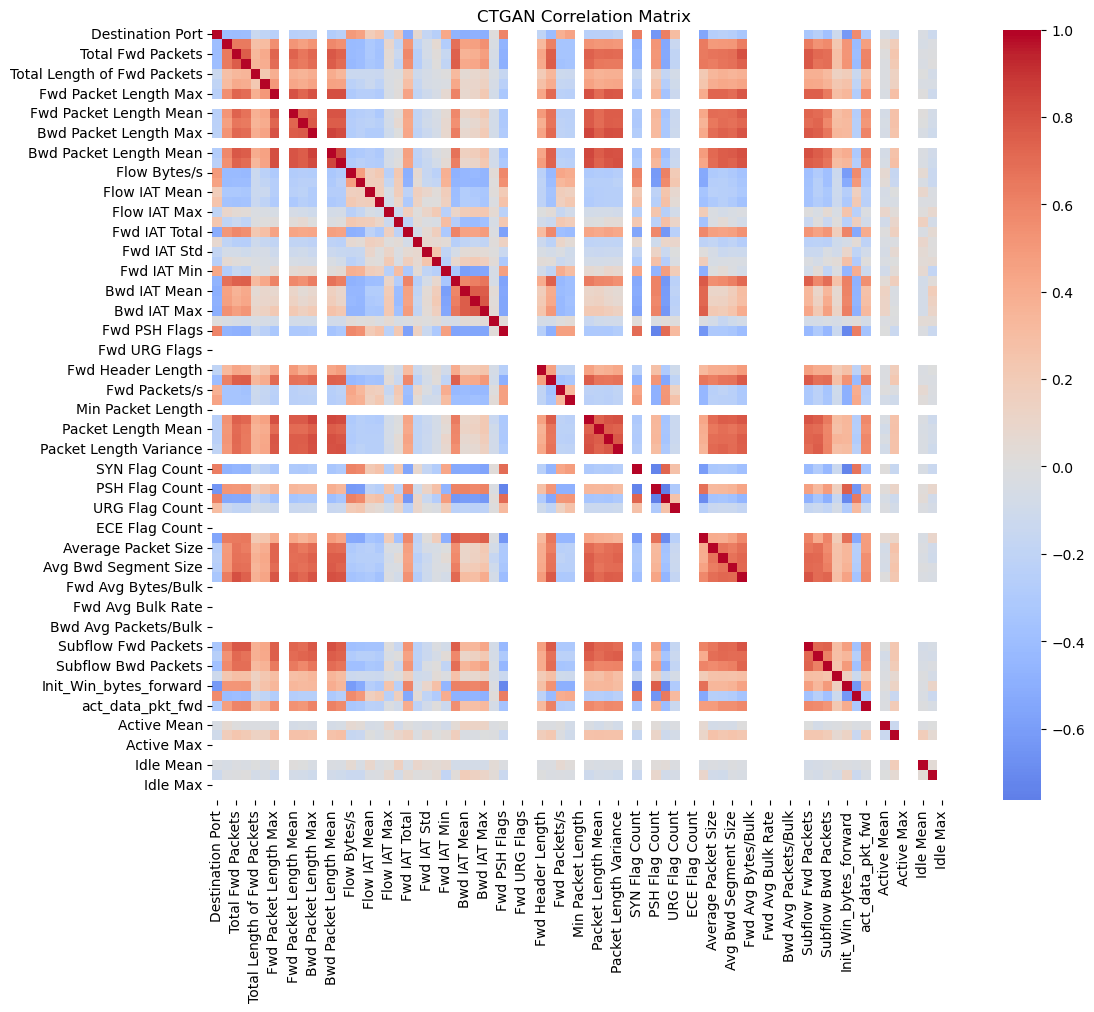

In [257]:
plt.figure(figsize=(12,10))

sns.heatmap(
    synthetic_df.corr(),
    cmap='coolwarm',
    center=0
)

plt.title('CTGAN Correlation Matrix')
plt.show()

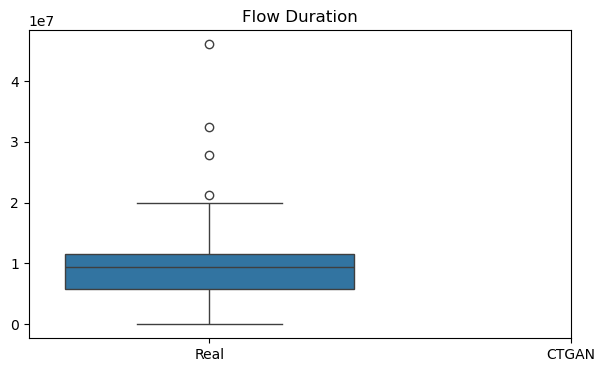

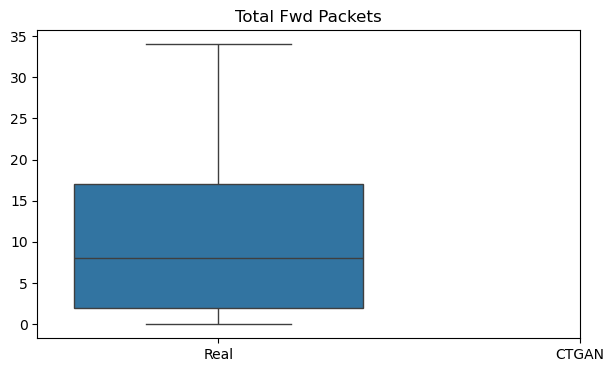

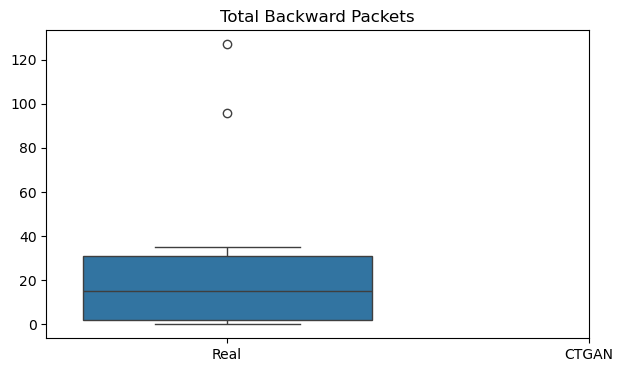

In [258]:
for col in cols:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        data=[
            ctgan_data[col],
            synthetic_df[col]
        ]
    )

    plt.xticks(
        [0,1],
        ['Real','CTGAN']
    )

    plt.title(col)

    plt.show()

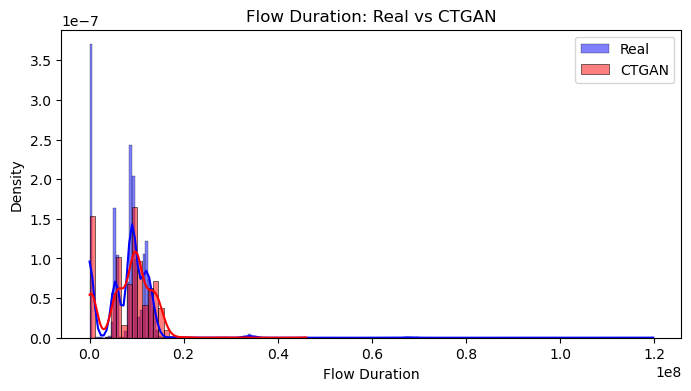

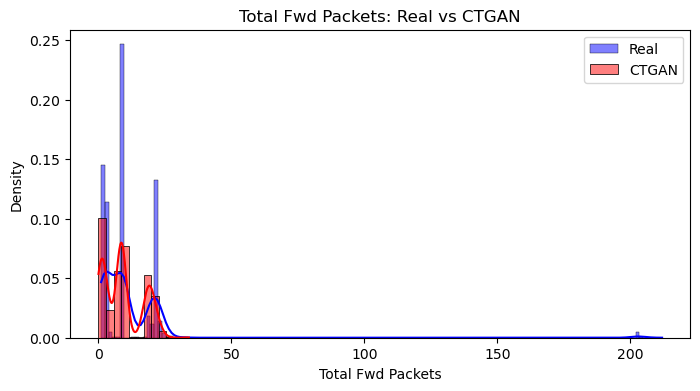

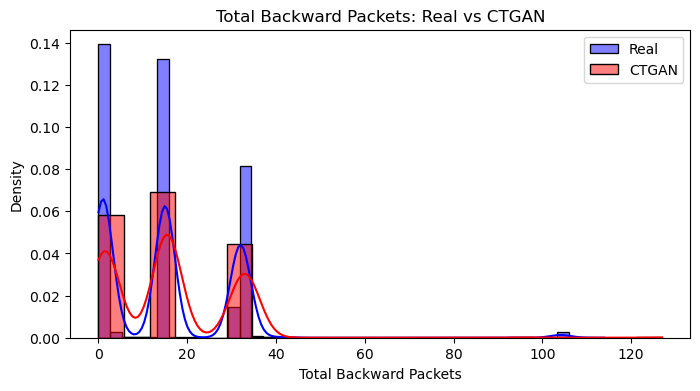

In [259]:
for col in cols:

    plt.figure(figsize=(8,4))

    sns.histplot(
        ctgan_data[col],
        color='blue',
        label='Real',
        stat='density',
        kde=True
    )

    sns.histplot(
        synthetic_df[col],
        color='red',
        label='CTGAN',
        stat='density',
        kde=True
    )

    plt.title(f'{col}: Real vs CTGAN')
    plt.legend()

    plt.show()

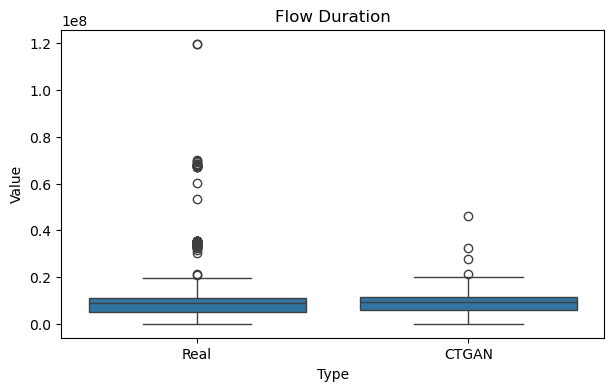

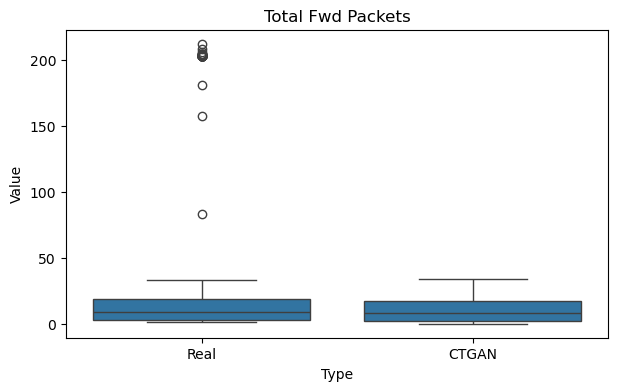

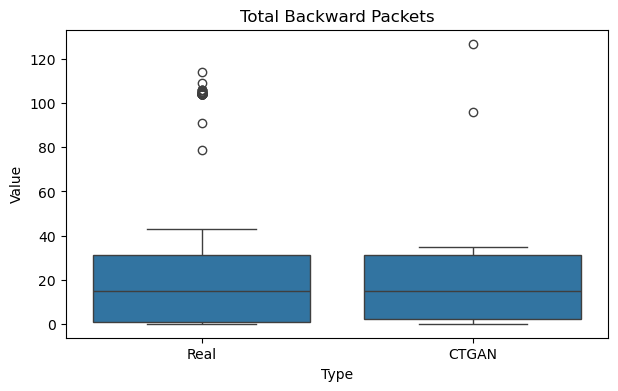

In [260]:
for col in cols:

    temp = pd.DataFrame({
        'Value': pd.concat([
            ctgan_data[col],
            synthetic_df[col]
        ]),
        'Type': (
            ['Real'] * len(ctgan_data)
            +
            ['CTGAN'] * len(synthetic_df)
        )
    })

    plt.figure(figsize=(7,4))

    sns.boxplot(
        data=temp,
        x='Type',
        y='Value'
    )

    plt.title(col)

    plt.show()

In [262]:
comparison = pd.DataFrame({
    'Real Mean': ctgan_data.mean(),
    'CTGAN Mean': synthetic_df.mean()
})

comparison['Difference'] = (
    comparison['CTGAN Mean']
    -
    comparison['Real Mean']
)

print(
    comparison.head(20)
)

                                Real Mean    CTGAN Mean     Difference
Destination Port             3.239780e+01  2.949400e+01      -2.903800
Flow Duration                7.663888e+06  8.408687e+06  744799.260860
Total Fwd Packets            1.120591e+01  9.046000e+00      -2.159908
Total Backward Packets       1.487198e+01  1.543100e+01       0.559016
Total Length of Fwd Packets  9.190035e+02  7.028200e+02    -216.183460
Total Length of Bwd Packets  1.516699e+03  6.632970e+02    -853.401811
Fwd Packet Length Max        1.876144e+02  2.095460e+02      21.931646
Fwd Packet Length Min        1.046842e-02  0.000000e+00      -0.010468
Fwd Packet Length Mean       3.310509e+01  3.584042e+01       2.735330
Fwd Packet Length Std        4.557842e+01  4.125619e+01      -4.322227
Bwd Packet Length Max        2.862757e+02  2.852590e+02      -1.016727
Bwd Packet Length Min        0.000000e+00  0.000000e+00       0.000000
Bwd Packet Length Mean       3.579730e+01  2.980753e+01      -5.989766
Bwd Pa

In [263]:
comparison['Percent Error'] = (
    abs(
        comparison['CTGAN Mean']
        -
        comparison['Real Mean']
    )
    /
    abs(comparison['Real Mean'])
) * 100

print(
    comparison.sort_values(
        'Percent Error'
    ).head(20)
)

                           Real Mean    CTGAN Mean     Difference  \
min_seg_size_forward    3.200000e+01  3.200000e+01       0.000000   
Fwd IAT Max             2.696387e+06  2.691966e+06   -4420.940266   
Bwd Packet Length Max   2.862757e+02  2.852590e+02      -1.016727   
act_data_pkt_fwd        7.097232e+00  7.056000e+00      -0.041232   
PSH Flag Count          7.936480e-01  8.000000e-01       0.006352   
Init_Win_bytes_forward  2.322925e+04  2.341651e+04     187.259791   
Bwd IAT Total           6.776791e+06  6.869250e+06   92458.940304   
Fwd PSH Flags           1.735273e-01  1.760000e-01       0.002473   
Fwd IAT Total           6.036481e+06  5.921650e+06 -114831.703661   
Down/Up Ratio           6.542761e-01  6.690000e-01       0.014724   
Packet Length Std       6.167034e+01  5.998412e+01      -1.686220   
ACK Flag Count          2.063520e-01  2.120000e-01       0.005648   
Fwd IAT Mean            8.515063e+05  8.795078e+05   28001.470245   
Fwd Header Length.1     3.650901e+

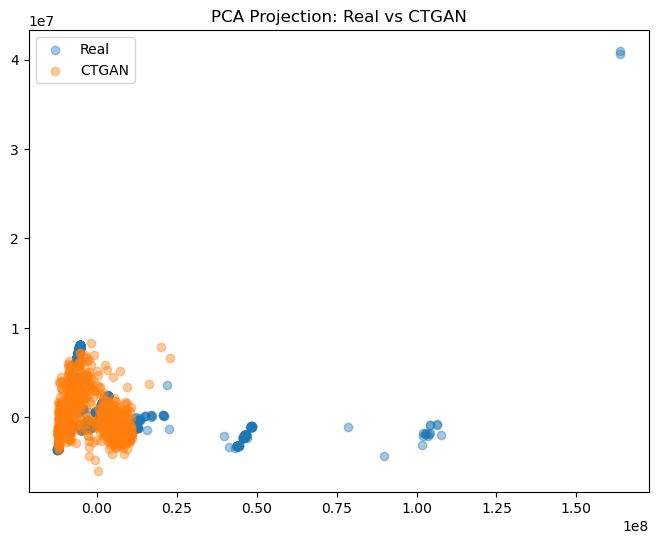

In [264]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

real_pca = pca.fit_transform(ctgan_data)

synthetic_pca = pca.transform(synthetic_df)

plt.figure(figsize=(8,6))

plt.scatter(
    real_pca[:,0],
    real_pca[:,1],
    alpha=0.4,
    label='Real'
)

plt.scatter(
    synthetic_pca[:,0],
    synthetic_pca[:,1],
    alpha=0.4,
    label='CTGAN'
)

plt.legend()

plt.title(
    'PCA Projection: Real vs CTGAN'
)

plt.show()

below code is useless dont yeild any output

In [171]:
combined_df['Label'].value_counts().sort_index()

Label
0     2095057
1        1948
2      128014
3       10286
4      172846
5        5228
6        5385
7        5931
8          11
9          36
10      90694
11       3219
12       1470
13         21
14        652
Name: count, dtype: int64

In [176]:
combined_df['Label']

0          0
1          0
2          0
3          0
4          0
          ..
2830738    0
2830739    0
2830740    0
2830741    0
2830742    0
Name: Label, Length: 2520798, dtype: int64

In [177]:
brute_xss_df = combined_df[
    combined_df['Label'].isin([
        label_mapping['Web Attack � Brute Force'],
        label_mapping['Web Attack � XSS']
    ])
]

In [178]:
xss_df = combined_df[
    combined_df['Label']
    == label_mapping['Web Attack � XSS']
]

brute_df = combined_df[
    combined_df['Label']
    == label_mapping['Web Attack � Brute Force']
]

print(xss_df.shape)
print(brute_df.shape)

(652, 79)
(1470, 79)


In [179]:
xss_features = xss_df.drop(
    columns=['Label']
)

In [180]:
constant_cols_xss = [
    col for col in xss_features.columns
    if xss_features[col].nunique() <= 1
]

print(len(constant_cols_xss))

28


In [181]:
xss_features = xss_features.drop(
    columns=constant_cols_xss
)

print(xss_features.shape)

(652, 50)


In [182]:
from ctgan import CTGAN

ctgan_xss = CTGAN(
    epochs=50,
    verbose=True
)

ctgan_xss.fit(
    xss_features
)

Gen. (-05.11) | Discrim. (-00.21): 100%|██████████| 50/50 [00:10<00:00,  4.55it/s]


In [183]:
synthetic_xss = ctgan_xss.sample(
    1800
)

In [184]:
synthetic_xss['Label'] = (
    label_mapping['Web Attack � XSS']
)

In [185]:
print(len(constant_cols_xss))
print(xss_features.shape)

28
(652, 50)


In [186]:
from ctgan import CTGAN

ctgan_xss = CTGAN(
    epochs=50,
    verbose=True
)

ctgan_xss.fit(
    xss_features
)

Gen. (-03.22) | Discrim. (-00.23): 100%|██████████| 50/50 [00:15<00:00,  3.22it/s]


In [187]:
synthetic_xss = ctgan_xss.sample(
    1800
)

In [188]:
for col in constant_cols_xss:
    synthetic_xss[col] = xss_df[col].iloc[0]

In [189]:
synthetic_xss = synthetic_xss[
    xss_df.drop(columns=['Label']).columns
]

In [190]:
synthetic_xss['Label'] = (
    label_mapping['Web Attack � XSS']
)

In [191]:
synthetic_xss = ctgan_xss.sample(500)

In [193]:
xss_features.describe()


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Mean,...,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd
count,6.520000e+02,652.000000,652.000000,652.000000,652.000000,652.000000,652.000000,652.000000,652.000000,652.000000,...,652.000000,652.000000,652.000000,652.000000,652.000000,652.000000,652.000000,652.000000,652.000000,652.000000
mean,6.715357e+06,7.903374,3.573620,1197.619632,4519.015337,20.197853,7.595968,8.693407,98.817485,53.165765,...,7.595968,53.165765,260.625767,7.903374,1197.619632,3.573620,4519.015337,28210.542945,26905.725460,2.486196
std,9.592863e+06,30.779702,15.985279,7459.492105,28061.467673,104.282196,40.055935,44.783656,607.740032,286.729861,...,40.055935,286.729861,985.008164,30.779702,7459.492105,15.985279,28061.467673,5179.159691,7377.196252,15.433564
min,4.000000e+00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,255.000000,-1.000000,0.000000
25%,5.191745e+06,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,104.000000,3.000000,0.000000,1.000000,0.000000,29200.000000,28960.000000,0.000000
50%,5.398910e+06,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,104.000000,3.000000,0.000000,1.000000,0.000000,29200.000000,28960.000000,0.000000
75%,5.605595e+06,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,104.000000,3.000000,0.000000,1.000000,0.000000,29200.000000,28960.000000,0.000000
max,7.020306e+07,212.000000,114.000000,48985.000000,183700.000000,585.000000,241.305419,253.458284,7926.000000,1773.202532,...,241.305419,1773.202532,6792.000000,212.000000,48985.000000,114.000000,183700.000000,29200.000000,28960.000000,101.000000


In [194]:
synthetic_xss.describe()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Mean,...,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd
count,5.000000e+02,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,6.216753e+06,5.64200,2.562000,622.272000,12456.512000,9.664000,8.375304,1.648383,136.884000,85.726160,...,0.412336,22.338146,240.154000,10.784000,1423.634000,4.064000,987.206000,28225.734000,27910.10200,3.558000
std,7.836336e+06,25.88958,14.962952,6287.285591,50511.198165,84.440983,43.091465,28.358099,767.742308,399.606592,...,21.998627,175.423570,928.851008,41.746315,7228.127817,17.926143,20423.177434,4869.045275,5364.82024,17.412554
min,-4.170592e+06,-2.00000,-11.000000,-10656.000000,-3231.000000,-16.000000,-4.652315,-6.892705,-1430.000000,-28.051914,...,-13.353116,-41.740361,-29.000000,-1.000000,-1026.000000,-11.000000,-31426.000000,-15329.000000,-11411.00000,-2.000000
25%,4.897786e+06,0.00000,-1.000000,-593.000000,575.500000,-9.000000,-0.842586,-4.122416,-32.250000,7.635444,...,-3.840783,-9.377231,73.000000,2.000000,108.750000,1.000000,-2722.500000,28724.000000,28471.25000,0.000000
50%,5.415987e+06,1.00000,0.000000,-293.000000,1815.500000,-5.000000,0.905059,-2.399551,-2.000000,19.728446,...,-2.394188,2.109330,117.500000,4.000000,400.500000,2.000000,-1728.000000,28920.000000,28765.50000,1.000000
75%,5.952156e+06,3.00000,1.000000,33.250000,2801.500000,1.000000,2.719031,-0.444513,30.000000,29.817398,...,-0.369325,14.384305,162.000000,5.000000,682.250000,2.000000,-701.500000,29162.250000,29075.00000,1.000000
max,1.021482e+08,246.00000,138.000000,61461.000000,319502.000000,790.000000,384.577684,336.282799,9196.000000,3264.999349,...,270.147716,2456.417835,9606.000000,314.000000,79908.000000,188.000000,211390.000000,29776.000000,30002.00000,165.000000


In [195]:
synthetic_xss = ctgan_xss.sample(1800)

In [196]:
augmented_df = pd.concat(
    [combined_df, synthetic_xss],
    ignore_index=True
)

In [198]:
augmented_df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
count,2.520798e+06,2.522598e+06,2.522598e+06,2.522598e+06,2.522598e+06,2.522598e+06,2.522598e+06,2.520798e+06,2.522598e+06,2.522598e+06,...,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06
mean,8.690590e+03,1.658437e+07,1.027988e+01,1.156657e+01,6.118378e+02,1.813593e+04,2.310696e+02,1.920349e+01,6.346479e+01,7.727103e+01,...,-3.082233e+03,9.157847e+04,4.619177e+04,1.720171e+05,6.546359e+04,9.337367e+06,5.657941e+05,9.763770e+06,8.892671e+06,8.132294e-01
std,1.901280e+04,3.522196e+07,7.941370e+02,1.056545e+03,1.058552e+04,2.397322e+06,7.561318e+02,6.079834e+01,1.954916e+02,2.967835e+02,...,1.149758e+06,6.866503e+05,4.165844e+05,1.085571e+06,6.111585e+05,2.484818e+07,4.874169e+06,2.561746e+07,2.458143e+07,2.193234e+00
min,0.000000e+00,-5.732544e+06,-2.000000e+00,-1.300000e+01,-9.761000e+03,-1.329600e+04,-1.600000e+01,0.000000e+00,-2.279346e+01,-7.045653e+00,...,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,2.090000e+02,2.000000e+00,1.000000e+00,1.200000e+01,6.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,5.067400e+04,2.000000e+00,2.000000e+00,6.600000e+01,1.560000e+02,4.000000e+01,2.000000e+00,3.611111e+01,0.000000e+00,...,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,5.337802e+06,6.000000e+00,5.000000e+00,3.320000e+02,1.007000e+03,2.020000e+02,3.700000e+01,5.200000e+01,7.413913e+01,...,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08,1.400000e+01


In [199]:
numeric_cols = synthetic_xss.select_dtypes(include=['number']).columns

synthetic_xss[numeric_cols] = synthetic_xss[numeric_cols].clip(lower=0)

In [200]:
count_cols = [
    'Total Fwd Packets',
    'Total Backward Packets',
    'Subflow Fwd Packets',
    'Subflow Bwd Packets',
    'act_data_pkt_fwd'
]

for col in count_cols:
    synthetic_xss[col] = synthetic_xss[col].round()

In [201]:
for col in constant_cols_xss:
    synthetic_xss[col] = xss_df[col].iloc[0]

In [202]:
original_feature_cols = xss_df.drop(columns=['Label']).columns

synthetic_xss = synthetic_xss[
    original_feature_cols
]

In [203]:
synthetic_xss['Label'] = (
    label_mapping['Web Attack � XSS']
)

In [204]:
print(synthetic_xss.shape)
print(synthetic_xss['Label'].value_counts())

(1800, 79)
Label
14    1800
Name: count, dtype: int64


In [205]:
augmented_df = pd.concat(
    [combined_df, synthetic_xss],
    ignore_index=True
)

In [206]:
augmented_df['Label'].value_counts()

Label
0     2095057
4      172846
2      128014
10      90694
3       10286
7        5931
6        5385
5        5228
11       3219
14       2452
1        1948
12       1470
9          36
13         21
8          11
Name: count, dtype: int64

In [207]:
X_aug = augmented_df.drop('Label', axis=1)
y_aug = augmented_df['Label']

In [208]:
from sklearn.model_selection import train_test_split

X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(
    X_aug,
    y_aug,
    test_size=0.2,
    random_state=42,
    stratify=y_aug
)

In [209]:
pipeline.fit(X_train_aug)

NameError: name 'pipeline' is not defined

In [ ]:
# X_train_aug_processed = pipeline.transform(X_train_aug)
# X_test_aug_processed = pipeline.transform(X_test_aug)

In [210]:
# Removed notebook-specific command for portability
# %who

Adam	 BatchNormalization	 CTGAN	 ColumnTransformer	 Dense	 Dropout	 EarlyStopping	 LabelEncoder	 MinMaxScaler	 
Pipeline	 Sequential	 StandardScaler	 X	 X_aug	 X_test	 X_test_aug	 X_test_processed	 X_train	 
X_train_aug	 X_train_processed	 accuracy_score	 augmented_df	 batch_size	 brute_df	 brute_xss_df	 class_counts	 classification_report	 
cm	 col	 cols	 combined_df	 confusion_matrix	 constant_cols	 constant_cols_xss	 count_cols	 csv_files	 
ctgan	 ctgan_data	 ctgan_data_reduced	 ctgan_xss	 d_loss	 d_loss_fake	 d_loss_real	 dataframes	 df	 
df_backup	 discriminator	 discrimonator	 early_stop	 epoch	 epochs	 extract_path	 fake_labels	 fake_samples	 
feature	 feature_dim	 file	 fitted_scaler	 g_loss	 gan	 gan_X	 gan_X_reduced	 gan_data_scaled	 
gan_numeric_features	 gan_pipeline	 gan_preprocessor	 gan_scaler	 generator	 glob	 history	 i	 idx	 
label_encoder	 label_mapping	 minority_classes	 minority_df	 misleading_labels	 model	 noise	 noise_dim	 np	 
null_values	 numeric_cols	 numeric

In [211]:
print(type(preprocessor))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [212]:
X_train_aug_processed = preprocessor.fit_transform(
    X_train_aug
)

X_test_aug_processed = preprocessor.transform(
    X_test_aug
)

In [213]:
print(X_train_aug_processed.shape)
print(X_test_aug_processed.shape)

(2018078, 78)
(504520, 78)


In [214]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,831 (245.44 KB)

 Trainable params: 20,943 (81.81 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 41,888 (163.63 KB)

In [215]:
print(model.input_shape)
print(model.output_shape)

(None, 78)
(None, 15)


In [216]:
new_model = Sequential([
    Dense(128, activation='relu', input_shape=(78,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(15, activation='softmax')
])

c:\Users\sidgu\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [217]:
new_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [218]:
history = new_model.fit(
    X_train_aug_processed,
    y_train_aug,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
25226/25226 ━━━━━━━━━━━━━━━━━━━━ 100s 4ms/step - accuracy: 0.9703 - loss: 0.0783 - val_accuracy: 0.9790 - val_loss: 0.0475
Epoch 2/50
25226/25226 ━━━━━━━━━━━━━━━━━━━━ 81s 3ms/step - accuracy: 0.9775 - loss: 0.0532 - val_accuracy: 0.9798 - val_loss: 0.0460
Epoch 3/50
25226/25226 ━━━━━━━━━━━━━━━━━━━━ 79s 3ms/step - accuracy: 0.9794 - loss: 0.0486 - val_accuracy: 0.9860 - val_loss: 0.0380
Epoch 4/50
25226/25226 ━━━━━━━━━━━━━━━━━━━━ 83s 3ms/step - accuracy: 0.9811 - loss: 0.0457 - val_accuracy: 0.9852 - val_loss: 0.0364
Epoch 5/50
25226/25226 ━━━━━━━━━━━━━━━━━━━━ 82s 3ms/step - accuracy: 0.9814 - loss: 0.0448 - val_accuracy: 0.9774 - val_loss: 0.0438
Epoch 6/50
25226/25226 ━━━━━━━━━━━━━━━━━━━━ 80s 3ms/step - accuracy: 0.9833 - loss: 0.0417 - val_accuracy: 0.9878 - val_loss: 0.0311
Epoch 7/50
25226/25226 ━━━━━━━━━━━━━━━━━━━━ 79s 3ms/step - accuracy: 0.9854 - loss: 0.0381 - val_accuracy: 0.9815 - val_loss: 0.0482
Epoch 8/50
25226/25226 ━━━━━━━━━━━━━━━━━━━━ 80s 3ms/step - accuracy:

In [219]:
y_pred_probs = new_model.predict(
    X_test_aug_processed
)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

15767/15767 ━━━━━━━━━━━━━━━━━━━━ 23s 1ms/step


In [220]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_aug,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.99      0.99    419012
           1       0.85      0.34      0.49       390
           2       1.00      0.98      0.99     25603
           3       0.97      0.96      0.96      2057
           4       0.99      0.92      0.96     34569
           5       0.84      0.93      0.88      1046
           6       0.84      0.87      0.86      1077
           7       0.97      0.69      0.80      1186
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       0.85      0.89      0.87     18139
          11       0.99      0.90      0.94       644
          12       0.60      0.04      0.08       294
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       490

    accuracy                           0.98    504520
   macro avg       0.66      0.57      0.59    504520
weighted avg       0.98   

c:\Users\sidgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sidgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sidgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [221]:
for k, v in label_mapping.items():
    print(v, "->", k)

0 -> BENIGN
1 -> Bot
2 -> DDoS
3 -> DoS GoldenEye
4 -> DoS Hulk
5 -> DoS Slowhttptest
6 -> DoS slowloris
7 -> FTP-Patator
8 -> Heartbleed
9 -> Infiltration
10 -> PortScan
11 -> SSH-Patator
12 -> Web Attack � Brute Force
13 -> Web Attack � Sql Injection
14 -> Web Attack � XSS


In [222]:
augmented_df['Label'].value_counts().sort_index()

Label
0     2095057
1        1948
2      128014
3       10286
4      172846
5        5228
6        5385
7        5931
8          11
9          36
10      90694
11       3219
12       1470
13         21
14       2452
Name: count, dtype: int64

In [223]:
augmented_df['Label'].value_counts().sort_index()

Label
0     2095057
1        1948
2      128014
3       10286
4      172846
5        5228
6        5385
7        5931
8          11
9          36
10      90694
11       3219
12       1470
13         21
14       2452
Name: count, dtype: int64

In [224]:
print(
    classification_report(
        y_test_aug,
        y_pred,
        target_names=label_encoder.classes_
    )
)

c:\Users\sidgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sidgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                            precision    recall  f1-score   support

                    BENIGN       0.98      0.99      0.99    419012
                       Bot       0.85      0.34      0.49       390
                      DDoS       1.00      0.98      0.99     25603
             DoS GoldenEye       0.97      0.96      0.96      2057
                  DoS Hulk       0.99      0.92      0.96     34569
          DoS Slowhttptest       0.84      0.93      0.88      1046
             DoS slowloris       0.84      0.87      0.86      1077
               FTP-Patator       0.97      0.69      0.80      1186
                Heartbleed       0.00      0.00      0.00         2
              Infiltration       0.00      0.00      0.00         7
                  PortScan       0.85      0.89      0.87     18139
               SSH-Patator       0.99      0.90      0.94       644
  Web Attack � Brute Force       0.60      0.04      0.08       294
Web Attack � Sql Injection       0.00      0.00

c:\Users\sidgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


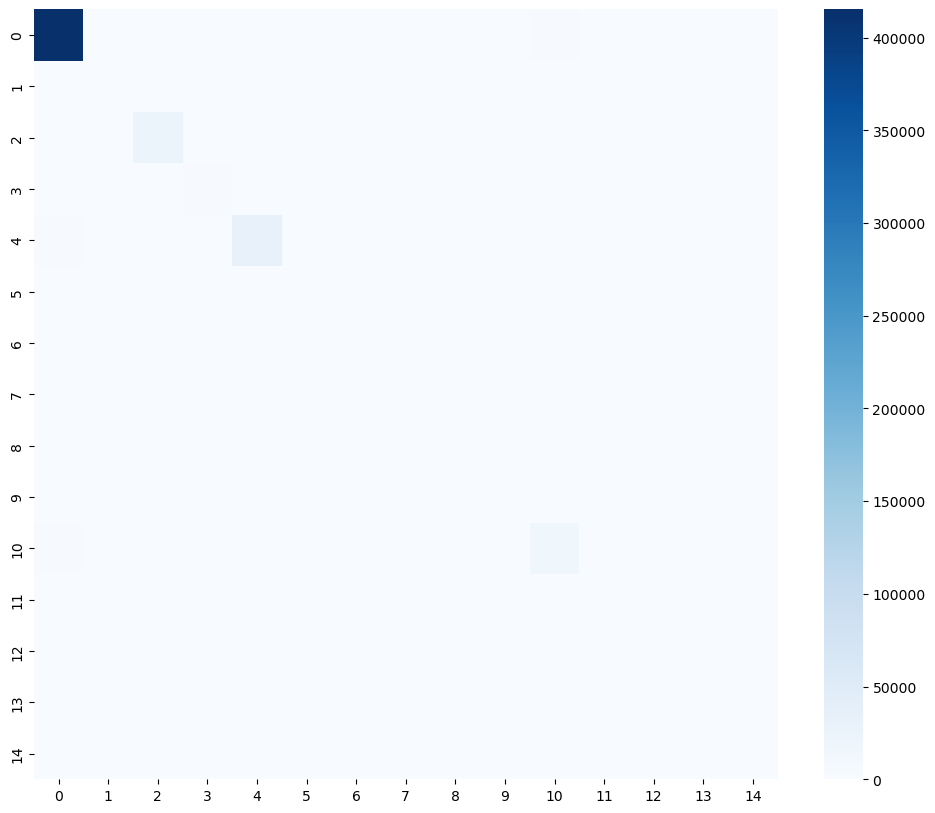

In [225]:
cm = confusion_matrix(y_test_aug, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.show()

In [226]:
xss_label = label_mapping['Web Attack � XSS']

xss_idx = np.where(y_test_aug == xss_label)[0]

print(
    pd.Series(y_pred[xss_idx])
    .value_counts()
    .head(10)
)

0    488
5      1
7      1
Name: count, dtype: int64


In [227]:
xss_label = label_mapping['Web Attack � XSS']

xss_idx = np.where(y_test_aug == xss_label)[0]

print(pd.Series(y_pred[xss_idx]).value_counts())

0    488
5      1
7      1
Name: count, dtype: int64
